### EDA e identificación de errores
Parto de los CSV obtenidos de SQL para que las columnas tengan los nombres de identificación que usamos en los KPI.

In [101]:
#Todos los módulos a usar:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from google.colab import files

In [102]:
archivos_subidos = files.upload()

print("\nArchivos cargados:")
for nombre_archivo in archivos_subidos.keys():
    print(f"- {nombre_archivo}")


Archivos cargados:


Subidos los CSV generaré nombres genéricos para que las fórmulas sirvan simplemente cambiando la siguiente celda.

In [103]:
# Nombres de los archivos
csv_clientes = "clientes.csv"
csv_lote = "lote.csv"
csv_marca = "marca.csv"
csv_producto = "producto.csv"
csv_proveedor = "proveedor.csv"
csv_subtipo = "subtipo.csv"
csv_tipo = "tipo.csv"
csv_venta = "venta.csv"

# Carga de los nuevos CSV directamente desde Colab
df_clientes = pd.read_csv(csv_clientes)
df_lote = pd.read_csv(csv_lote)
df_marca = pd.read_csv(csv_marca)
df_producto = pd.read_csv(csv_producto)
df_proveedor = pd.read_csv(csv_proveedor)
df_subtipo = pd.read_csv(csv_subtipo)
df_tipo = pd.read_csv(csv_tipo)
df_venta = pd.read_csv(csv_venta)

# Carga de los CSV. Ha presentado algo de problemas porque es un csv separado por ;
# y pandas usa por defecto UTF-8, en caso de cargar con UTF-8 usar las que están en texto.
# df_clientes = pd.read_csv(csv_clientes, sep=";", encoding="latin-1")
# df_lote = pd.read_csv(csv_lote, sep=";", encoding="latin-1")
# df_marca = pd.read_csv(csv_marca, sep=";", encoding="latin-1")
# df_producto = pd.read_csv(csv_producto, sep=";", encoding="latin-1")
# df_proveedor = pd.read_csv(csv_proveedor, sep=";", encoding="latin-1")
# df_subtipo = pd.read_csv(csv_subtipo, sep=";", encoding="latin-1")
# df_tipo = pd.read_csv(csv_tipo, sep=";", encoding="latin-1")
# df_venta = pd.read_csv(csv_venta, sep=";", encoding="latin-1")

#df_clientes = pd.read_csv(csv_clientes)
#df_lote = pd.read_csv(csv_lote)
#df_marca = pd.read_csv(csv_marca)
#df_producto = pd.read_csv(csv_producto)
#df_proveedor = pd.read_csv(csv_proveedor)
#df_subtipo = pd.read_csv(csv_subtipo)
#df_tipo = pd.read_csv(csv_tipo)
#df_venta = pd.read_csv(csv_venta)

El EDA lo haremos orientado a los criterios de los datos del proyecto.

###**1er punto: Como mínimo se tarda un día desde que la fruta se recoge hasta que llega al cliente final.**

Consideraciones: no se trata de garantizar que haya mínimo 24 horas de margen sino validar que se produzca la recogida y la venta final en días distintos. Y que la fecha de venta sea posterior a la fecha de recogida.

In [104]:
# Unimos venta con la fecha de recogida de cada producto
df_criterio_1 = df_venta.merge(
    df_producto[["id_producto", "tiempo_recogida"]],
    on="id_producto",
    how="left"
).copy()

# Convertimos las columnas a formato fecha y hora
df_criterio_1["tiempo_recogida"] = pd.to_datetime(
    df_criterio_1["tiempo_recogida"],
    errors="coerce"
)

df_criterio_1["tiempo_venta"] = pd.to_datetime(
    df_criterio_1["tiempo_venta"],
    errors="coerce"
)

# Extraemos únicamente el día, eliminando la hora
df_criterio_1["fecha_recogida"] = (
    df_criterio_1["tiempo_recogida"].dt.normalize()
)

df_criterio_1["fecha_venta"] = (
    df_criterio_1["tiempo_venta"].dt.normalize()
)

# Clasificamos los posibles errores
condiciones = [
    df_criterio_1["fecha_recogida"].isna()
    | df_criterio_1["fecha_venta"].isna(),

    df_criterio_1["fecha_venta"]
    < df_criterio_1["fecha_recogida"],

    df_criterio_1["fecha_venta"]
    == df_criterio_1["fecha_recogida"]
]

resultados = [
    "Fecha ausente o no válida",
    "Venta anterior a la recogida",
    "Recogida y venta en el mismo día"
]

df_criterio_1["error_criterio_1"] = np.select(
    condiciones,
    resultados,
    default=None
)

# Filtramos solo los registros que incumplen el criterio
errores_criterio_1 = df_criterio_1[
    df_criterio_1["error_criterio_1"].notna()
].copy()

# Resumen de errores detectados
resumen_criterio_1 = (
    errores_criterio_1["error_criterio_1"]
    .value_counts(dropna=False)
    .rename_axis("tipo_error")
    .reset_index(name="numero_registros")
)

print(f"Registros analizados: {len(df_criterio_1):,}")
print(f"Errores detectados: {len(errores_criterio_1):,}")

display(resumen_criterio_1)

display(
    errores_criterio_1[
        [
            "id_venta",
            "id_producto",
            "tiempo_recogida",
            "tiempo_venta",
            "error_criterio_1"
        ]
    ].head(20)
)

Registros analizados: 70,549
Errores detectados: 51,478


,tipo_error,numero_registros
0,Recogida y venta en el mismo día,50348
1,Venta anterior a la recogida,907
2,Fecha ausente o no válida,223


,id_venta,id_producto,tiempo_recogida,tiempo_venta,error_criterio_1
0,1,1,2025-09-19 08:00:00,2025-09-19 12:00:00,Recogida y venta en el mismo día
2,3,3,2025-09-19 17:00:00,2025-09-19 22:00:00,Recogida y venta en el mismo día
3,4,4,2025-09-28 06:00:00,2025-09-28 17:00:00,Recogida y venta en el mismo día
5,6,6,2025-09-08 19:00:00,2025-09-08 23:00:00,Recogida y venta en el mismo día
6,7,7,2025-09-19 12:00:00,2025-09-19 17:00:00,Recogida y venta en el mismo día
8,9,9,2025-09-27 20:00:00,2025-09-27 23:00:00,Recogida y venta en el mismo día
9,10,10,2025-09-13 04:00:00,2025-09-13 05:00:00,Recogida y venta en el mismo día
10,11,11,2025-09-06 12:00:00,2025-09-06 19:00:00,Recogida y venta en el mismo día
11,12,12,2025-09-14 12:00:00,2025-09-14 18:00:00,Recogida y venta en el mismo día
12,13,13,2025-09-18 09:00:00,2025-09-18 14:00:00,Recogida y venta en el mismo día


Se detectan muchos errores: 51,455

tipo_error	                        /numero_registros

Recogida y venta en el mismo día	  /50315

Venta anterior a la recogida	      /917

Fecha ausente o no válida	          /223

Sobreviven 19.094 registros a este criterio.

Nueva BBDD con el nuevo criterio.

Errores totales crit 1: 51,478

	Recogida y venta en el mismo día	50348
	Venta anterior a la recogida	907
	Fecha ausente o no válida	223

Guardo una relación de los valores supervivientes del criterio 1, es decir, una copia de las tablas venta y producto quitando los valores que no sobreviven al criterio.

In [105]:
# Identificadores de productos que cumplen el criterio 1
ids_productos_validos_c1 = (
    df_criterio_1.loc[
        df_criterio_1["error_criterio_1"].isna(),
        "id_producto"
    ]
    .drop_duplicates()
)

# Tabla producto superviviente
df_producto_superviviente_c1 = (
    df_producto.loc[
        df_producto["id_producto"].isin(ids_productos_validos_c1),
        df_producto.columns
    ]
    .copy()
    .reset_index(drop=True)
)

# Tabla venta superviviente
df_venta_superviviente_c1 = (
    df_venta.loc[
        df_venta["id_producto"].isin(ids_productos_validos_c1),
        df_venta.columns
    ]
    .copy()
    .reset_index(drop=True)
)

#Vista del resultado para comparar con el código anterior.
resumen_supervivientes_c1 = pd.DataFrame({
    "tabla": ["producto", "venta"],
    "registros_originales": [
        len(df_producto),
        len(df_venta)
    ],
    "registros_supervivientes": [
        len(df_producto_superviviente_c1),
        len(df_venta_superviviente_c1)
    ],
    "registros_excluidos": [
        len(df_producto) - len(df_producto_superviviente_c1),
        len(df_venta) - len(df_venta_superviviente_c1)
    ]
})

display(resumen_supervivientes_c1)

,tabla,registros_originales,registros_supervivientes,registros_excluidos
0,producto,70549,19071,51478
1,venta,70549,19071,51478


Consideración, tal y como hemos generado las tablas y nombrados las ventas, id_producto = id_venta porque ambos se generan a la vez.

In [106]:
display(df_producto_superviviente_c1.head(10))
display(df_venta_superviviente_c1.head(10))

,id_producto,t_id,id_tipo,id_subtipo,id_marca,id_proveedor,id_lote,coste_inicial,tiempo_recogida
0,2,Apple 10.png,1,1,34,30,8000,1.702296,2025-09-11 19:00:00
1,5,Apple 102.png,1,1,14,31,8003,2.473541,2025-09-18 17:00:00
2,8,Apple 105.png,1,1,11,10,8006,1.873714,2025-09-18 21:00:00
3,15,Apple 111.png,1,1,21,4,8013,1.892032,2025-09-16 15:00:00
4,16,Apple 112.png,1,1,5,29,8014,2.029022,2025-09-04 18:00:00
5,24,Apple 12.png,1,1,25,13,8022,2.163690,2025-09-23 18:00:00
6,30,Apple 125.png,1,1,32,14,8028,2.115233,2025-09-02 23:00:00
7,31,Apple 126.png,1,1,26,17,8029,1.929527,2025-09-24 23:00:00
8,33,Apple 128.png,1,1,7,13,8031,2.440790,2025-09-19 23:00:00
9,34,Apple 129.png,1,1,6,16,8032,1.890531,2025-09-17 20:00:00


,id_venta,id_producto,id_cliente,precio_venta,tiempo_venta,peso
0,2,2,6,3.425103,2025-09-12 02:00:00,141.647327
1,5,5,33,3.349878,2025-09-19 03:00:00,423.776864
2,8,8,22,3.736126,2025-09-19 04:00:00,341.153884
3,15,15,19,2.799800,2025-09-17 03:00:00,310.563183
4,16,16,18,3.309652,2025-09-05 01:00:00,246.110342
5,24,24,15,3.217438,2025-09-24 02:00:00,315.328261
6,30,30,3,2.996090,2025-09-03 12:00:00,374.863046
7,31,31,5,4.635405,2025-09-25 07:00:00,287.885447
8,33,33,10,4.059855,2025-09-20 06:00:00,271.320791
9,34,34,25,3.759744,2025-09-18 03:00:00,327.172184


###**2do criterio: A cada proveedor no se le pueden vender en un mismo día más de 100kg de una misma fruta.**

Consideraciones: no se trata de garantizar que haya mínimo 24 horas de margen sino validar la cantidad de producto *peso* que hay en cada día de *tiempo_recogida* para cada proveedor. Para evitar tener que hacer operaciones de conversión en los df usaremos el equivalente en gramos de los 100 Kg.

tiempo_recogida: unidad de tiempo (número entero) que representa el momento en que se produce la recoge el alimento del proveedor agrícola[...]

peso: peso en gramos del producto.

proveedor: proveedor agrícola.

Primero lo aplicaremos sobre la BBDD en bruto para analizar posibles patrones. Luego lo aplicaremos sobre los supervivientes del criterio 1 y crearemos la tabla de supervivientes acumulados.
El problema es que parece una forma arbitraria de aplicar los criterios, primero el 1, el 2, el 3...
Al finalizar el EDA podremos proponer una forma más lógica de aplicar los criterios en un orden concreto. El criterio 2 parece que deberá ocupar una de las últimas posiciones debido a que engloba un mayor número de transacciones y podría no tener que aplicarse si los criterios previos ya eliminan transacciones.

In [107]:
LIMITE_DIARIO_G = 100_000

# Relacionamos cada venta con los datos necesarios del producto
df_criterio_2 = df_venta.merge(
    df_producto[
        [
            "id_producto",
            "t_id",
            "id_tipo",
            "id_proveedor",
            "tiempo_recogida"
        ]
    ],
    on="id_producto",
    how="left",
    validate="many_to_one"
).copy()

# Convertimos la fecha
df_criterio_2["tiempo_recogida_dt"] = pd.to_datetime(
    df_criterio_2["tiempo_recogida"],
    errors="coerce"
)

# Eliminamos la influencia de la hora
df_criterio_2["fecha_recogida"] = (
    df_criterio_2["tiempo_recogida_dt"]
    .dt.normalize()
)

# Conversión para poder validar y sumar el peso
df_criterio_2["peso_evaluable_g"] = pd.to_numeric(
    df_criterio_2["peso"],
    errors="coerce"
)

Existen pesos negativos pero no parecen estar asociados a devoluciones, parecen errores de pesaje, así que no los tendremos en cuenta para el criterio 2. Ver tabla de errores para identificarlos.

In [108]:
# Registros que contienen toda la información necesaria sin nulos
# y sin pesos negativos
mascara_evaluable_c2 = (
    df_criterio_2["id_proveedor"].notna()
    & df_criterio_2["id_tipo"].notna()
    & df_criterio_2["fecha_recogida"].notna()
    & df_criterio_2["peso_evaluable_g"].notna()
    & (df_criterio_2["peso_evaluable_g"] > 0)
)

df_criterio_2["peso_total_grupo_g"] = np.nan
df_criterio_2["exceso_grupo_g"] = np.nan

# Sumamos el peso de cada combinación:
# proveedor + día + tipo de fruta
df_criterio_2.loc[
    mascara_evaluable_c2,
    "peso_total_grupo_g"
] = (
    df_criterio_2.loc[mascara_evaluable_c2]
    .groupby(
        [
            "id_proveedor",
            "fecha_recogida",
            "id_tipo"
        ]
    )["peso_evaluable_g"]
    .transform("sum")
)

# Calculamos cuánto se supera el límite
df_criterio_2.loc[
    mascara_evaluable_c2,
    "exceso_grupo_g"
] = (
    df_criterio_2.loc[
        mascara_evaluable_c2,
        "peso_total_grupo_g"
    ]
    - LIMITE_DIARIO_G
)

In [109]:
# Condiciones de error, ordenadas por prioridad
condiciones_c2 = [
    # Producto sin correspondencia en la tabla producto
    df_criterio_2["tiempo_recogida"].isna()
    & df_criterio_2["id_proveedor"].isna()
    & df_criterio_2["id_tipo"].isna(),

    # Fecha ausente o no interpretable
    df_criterio_2["fecha_recogida"].isna(),

    # Proveedor no informado
    df_criterio_2["id_proveedor"].isna(),

    # Tipo de fruta no informado
    df_criterio_2["id_tipo"].isna(),

    # Peso nulo, no numérico, igual a cero o negativo
    df_criterio_2["peso_evaluable_g"].isna()
    | (df_criterio_2["peso_evaluable_g"] <= 0),

    # Incumplimiento del criterio principal
    df_criterio_2["peso_total_grupo_g"] > LIMITE_DIARIO_G
]

tipos_error_c2 = [
    "Producto no encontrado en la tabla producto",
    "Fecha de recogida ausente o no válida",
    "Proveedor no informado",
    "Tipo de fruta no informado",
    "Peso ausente o no válido",
    "Más de 100.000 g de la misma fruta en el mismo día"
]

df_criterio_2["error_criterio_2"] = np.select(
    condiciones_c2,
    tipos_error_c2,
    default=None
)

# Tabla con todos los registros afectados
errores_criterio_2 = (
    df_criterio_2[
        df_criterio_2["error_criterio_2"].notna()
    ]
    .copy()
    .reset_index(drop=True)
)

In [110]:
resumen_criterio_2 = (
    errores_criterio_2["error_criterio_2"]
    .value_counts(dropna=False)
    .rename_axis("tipo_error")
    .reset_index(name="numero_registros")
)

print(f"Registros analizados: {len(df_criterio_2):,}")
print(f"Registros con error:  {len(errores_criterio_2):,}")

display(resumen_criterio_2)

Registros analizados: 70,549
Registros con error:  113


,tipo_error,numero_registros
0,Peso ausente o no válido,113


In [111]:
mascara_limite_superado_c2 = (
    df_criterio_2["peso_total_grupo_g"] > LIMITE_DIARIO_G
)

grupos_error_criterio_2 = (
    df_criterio_2.loc[mascara_limite_superado_c2]
    .groupby(
        [
            "id_proveedor",
            "fecha_recogida",
            "id_tipo"
        ],
        as_index=False
    )
    .agg(
        numero_ventas=("id_venta", "size"),
        numero_productos=("id_producto", "nunique"),
        peso_total_grupo_g=("peso_evaluable_g", "sum")
    )
)

grupos_error_criterio_2["exceso_grupo_g"] = (
    grupos_error_criterio_2["peso_total_grupo_g"]
    - LIMITE_DIARIO_G
)

grupos_error_criterio_2["error_criterio_2"] = (
    "Más de 100.000 g de la misma fruta en el mismo día"
)

grupos_error_criterio_2 = (
    grupos_error_criterio_2
    .sort_values(
        "peso_total_grupo_g",
        ascending=False
    )
    .reset_index(drop=True)
)

display(grupos_error_criterio_2)

,id_proveedor,fecha_recogida,id_tipo,numero_ventas,numero_productos,peso_total_grupo_g,exceso_grupo_g,error_criterio_2


In [112]:
columnas_errores_c2 = [
    "id_venta",
    "id_producto",
    "t_id",
    "id_proveedor",
    "id_tipo",
    "tiempo_recogida",
    "fecha_recogida",
    "peso",
    "peso_total_grupo_g",
    "exceso_grupo_g",
    "error_criterio_2"
]

display(
    errores_criterio_2[columnas_errores_c2]
    .sort_values(
        [
            "id_proveedor",
            "fecha_recogida",
            "id_tipo",
            "id_producto"
        ],
        na_position="last"
    )
)

,id_venta,id_producto,t_id,id_proveedor,id_tipo,tiempo_recogida,fecha_recogida,peso,peso_total_grupo_g,exceso_grupo_g,error_criterio_2
79,50859,50859,Orange001152.png,1,7,2025-09-09 01:00:00,2025-09-09,-10.991354,NaN,NaN,Peso ausente o no válido
37,25941,25941,GuavaÒÇé1865 resized.png,1,4,2025-09-10 01:00:00,2025-09-10,-7.758434,NaN,NaN,Peso ausente o no válido
69,44080,44080,Kiwi00660.png,1,5,2025-09-17 09:00:00,2025-09-17,-23.304431,NaN,NaN,Peso ausente o no válido
5,6403,6403,Apple F770.png,1,1,2025-09-24 12:00:00,2025-09-24,-66.097484,NaN,NaN,Peso ausente o no válido
107,67344,67344,Pomegranet002017.png,1,13,2025-09-24 21:00:00,2025-09-24,-12.341413,NaN,NaN,Peso ausente o no válido
...,...,...,...,...,...,...,...,...,...,...,...
41,28127,28127,GuavaÒÇé2357 resized resized.png,34,4,2025-09-28 17:00:00,2025-09-28,-14.031104,NaN,NaN,Peso ausente o no válido
85,54153,54153,Peach001406.png,34,8,2025-09-29 10:00:00,2025-09-29,-83.445477,NaN,NaN,Peso ausente o no válido
86,55427,55427,Peach002553.png,35,8,2025-09-22 10:00:00,2025-09-22,-4.500931,NaN,NaN,Peso ausente o no válido
109,67721,67721,Pomegranet00406.png,35,13,2025-09-25 20:00:00,2025-09-25,-44.419716,NaN,NaN,Peso ausente o no válido


In [113]:
# Identificadores de ventas afectadas
ids_ventas_error_c2 = (
    errores_criterio_2["id_venta"]
    .dropna()
    .unique()
)

# Identificadores de productos afectados
ids_productos_error_c2 = (
    errores_criterio_2["id_producto"]
    .dropna()
    .unique()
)

# Tabla venta limpia del criterio 2
df_venta_superviviente_c2 = (
    df_venta.loc[
        ~df_venta["id_venta"].isin(ids_ventas_error_c2),
        df_venta.columns
    ]
    .copy()
    .reset_index(drop=True)
)

# Tabla producto limpia del criterio 2
df_producto_superviviente_c2 = (
    df_producto.loc[
        ~df_producto["id_producto"].isin(ids_productos_error_c2),
        df_producto.columns
    ]
    .copy()
    .reset_index(drop=True)
)

In [114]:
display(df_venta_superviviente_c2.head(10))
display(df_producto_superviviente_c2.head(10))

,id_venta,id_producto,id_cliente,precio_venta,tiempo_venta,peso
0,1,1,6,4.909680,2025-09-19 12:00:00,264.195357
1,2,2,6,3.425103,2025-09-12 02:00:00,141.647327
2,3,3,20,3.178386,2025-09-19 22:00:00,151.923586
3,4,4,32,4.126968,2025-09-28 17:00:00,442.475391
4,5,5,33,3.349878,2025-09-19 03:00:00,423.776864
5,6,6,28,2.537187,2025-09-08 23:00:00,387.186499
6,7,7,34,3.630332,2025-09-19 17:00:00,336.645264
7,8,8,22,3.736126,2025-09-19 04:00:00,341.153884
8,9,9,26,3.549932,2025-09-27 23:00:00,179.132661
9,10,10,34,2.710149,2025-09-13 05:00:00,191.199349


,id_producto,t_id,id_tipo,id_subtipo,id_marca,id_proveedor,id_lote,coste_inicial,tiempo_recogida
0,1,Apple 1.png,1,1,26,1,7999,2.642048,2025-09-19 08:00:00
1,2,Apple 10.png,1,1,34,30,8000,1.702296,2025-09-11 19:00:00
2,3,Apple 100.png,1,1,7,25,8001,1.176703,2025-09-19 17:00:00
3,4,Apple 101.png,1,1,11,11,8002,2.314693,2025-09-28 06:00:00
4,5,Apple 102.png,1,1,14,31,8003,2.473541,2025-09-18 17:00:00
5,6,Apple 103.png,1,1,7,34,8004,1.056429,2025-09-08 19:00:00
6,7,Apple 104.png,1,1,32,6,8005,1.770176,2025-09-19 12:00:00
7,8,Apple 105.png,1,1,11,10,8006,1.873714,2025-09-18 21:00:00
8,9,Apple 106.png,1,1,14,24,8007,2.196754,2025-09-27 20:00:00
9,10,Apple 107.png,1,1,27,9,8008,1.597692,2025-09-13 04:00:00


### 3er criterio: No hay marcas que produzcan más de un tipo de fruta.

In [171]:
# Relación marca-tipo de todos los productos
df_marca_tipo = (
    df_producto[
        ["id_marca", "id_tipo"]
    ]
    .copy()
    .reset_index(drop=True)
)

# Combinaciones únicas entre marca y tipo de fruta
df_marca_tipo_unicos = (
    df_marca_tipo
    .drop_duplicates()
    .sort_values(
        ["id_marca", "id_tipo"]
    )
    .reset_index(drop=True)
)

# Número de tipos de fruta diferentes asociados a cada marca
df_tipos_por_marca = (
    df_marca_tipo_unicos
    .groupby(
        "id_marca",
        as_index=False
    )
    .size()
    .rename(
        columns={"size": "tipos_fruta"}
    )
    .sort_values(
        ["tipos_fruta", "id_marca"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

display(df_tipos_por_marca)


,id_marca,tipos_fruta
0,1,15
1,2,15
2,3,15
3,4,15
4,5,15
5,6,15
6,7,15
7,8,15
8,9,15
9,10,15


In [116]:
# Resumen del criterio: marcas asociadas a más de un tipo de fruta
df_resumen_marcas = pd.DataFrame({
    "total_marcas": [
        df_tipos_por_marca["id_marca"].nunique()
    ],
    "marcas_mas_de_un_tipo": [
        (df_tipos_por_marca["tipos_fruta"] > 1).sum()
    ]
})

display(df_resumen_marcas)

,total_marcas,marcas_mas_de_un_tipo
0,35,35


Parece que todas las marcas distribuyen todos los tipos de frutas.
Vamos a ver si existe un tipo de fruta mayoritaria por marca.

Como solo hay 15 tipos de frutas no es descabellado hacer un nuevo df con 15 columnas, una por cada tipo de fruta a ver si detectamos algún patrón.

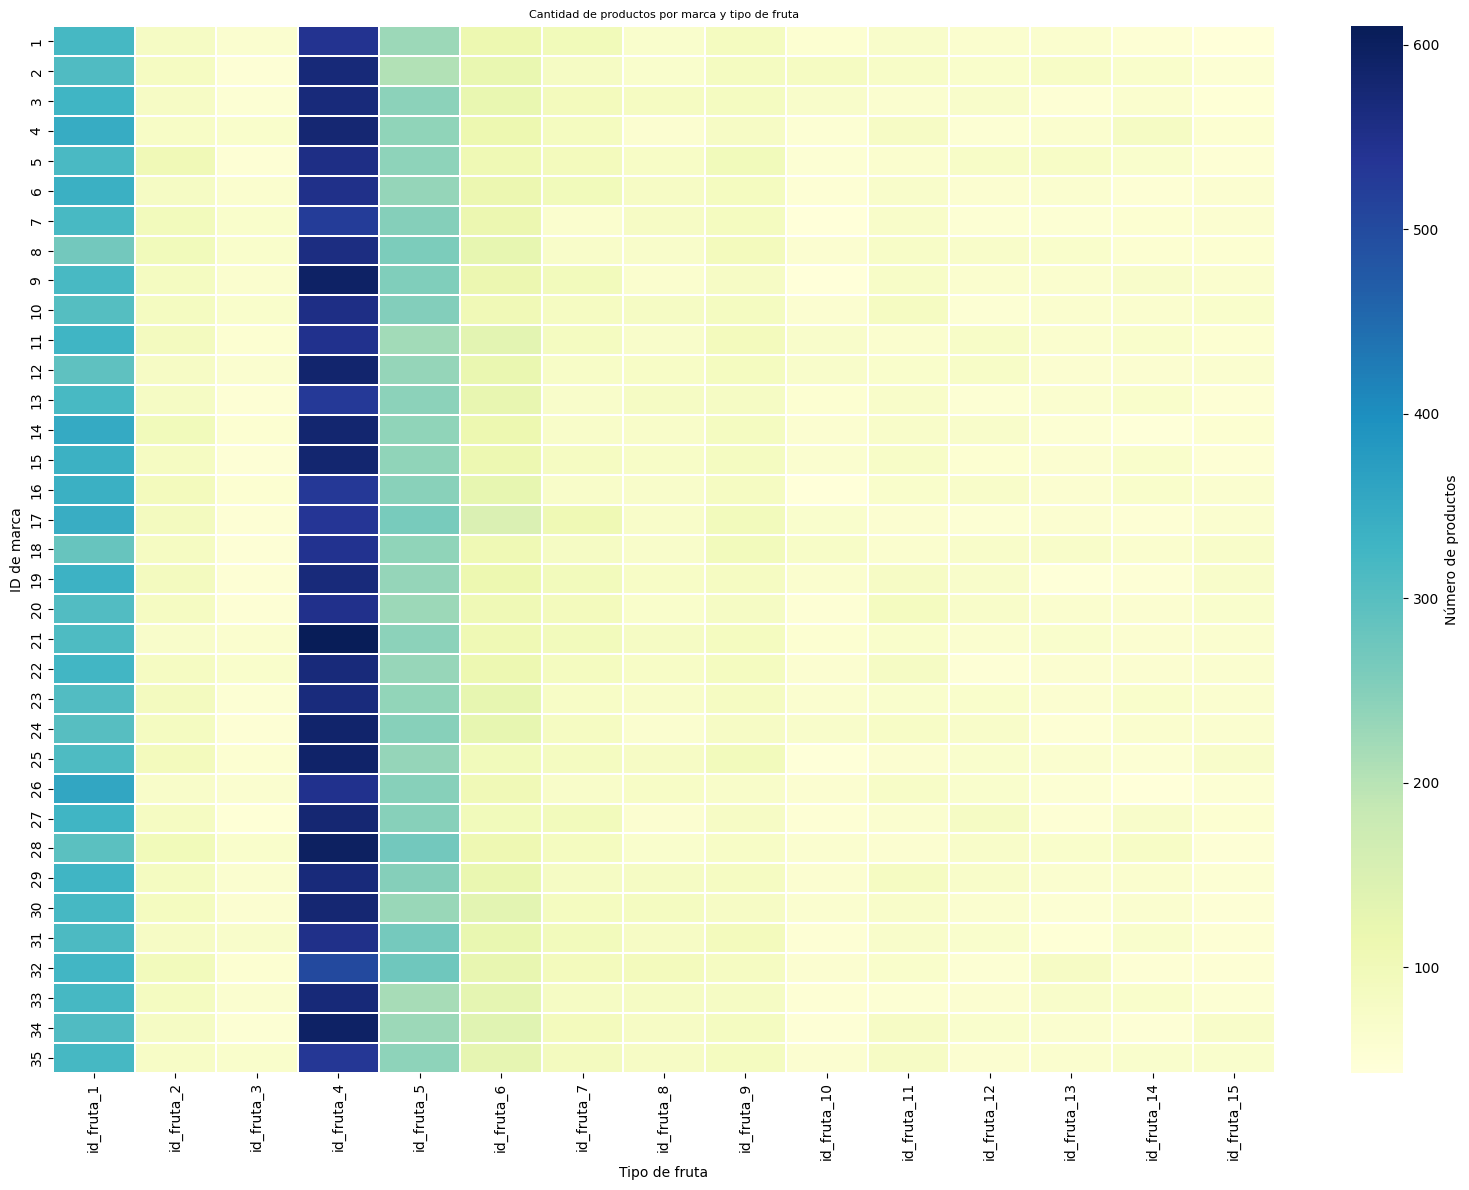

,id_marca,id_fruta_1,id_fruta_2,id_fruta_3,id_fruta_4,id_fruta_5,id_fruta_6,id_fruta_7,id_fruta_8,id_fruta_9,id_fruta_10,id_fruta_11,id_fruta_12,id_fruta_13,id_fruta_14,id_fruta_15
0,1,321,82,61,543,227,114,99,66,88,57,70,65,63,53,45
1,2,310,84,50,571,206,121,81,66,87,83,76,68,77,69,55
2,3,328,80,56,568,244,122,92,85,87,71,61,70,53,65,48
3,4,346,77,69,577,239,115,89,59,80,55,80,55,64,82,58
4,5,316,104,53,555,242,108,92,77,98,55,64,75,78,67,54
5,6,339,82,64,552,234,117,97,80,88,53,70,59,62,53,60
6,7,319,95,68,524,249,118,63,80,89,45,73,56,56,57,60
7,8,271,97,69,560,259,125,72,71,92,59,75,73,68,57,58
8,9,318,87,64,594,255,118,95,65,80,43,75,64,64,70,64
9,10,304,86,68,555,253,105,83,82,86,59,83,56,64,64,68


In [172]:
# Tabla cruzada: una fila por marca y una columna por tipo de fruta

df_marca_frutas = pd.crosstab(
    index=df_producto["id_marca"],
    columns=df_producto["id_tipo"]
)

# Garantizamos que aparezcan los 15 tipos de fruta
df_marca_frutas = df_marca_frutas.reindex(
    columns=range(1, 16),
    fill_value=0
)

# Renombramos las columnas
df_marca_frutas.columns = [
    f"id_fruta_{id_tipo}"
    for id_tipo in df_marca_frutas.columns
]

# Convertimos id_marca nuevamente en columna
df_marca_frutas = (
    df_marca_frutas
    .reset_index()
)

# Eliminamos el nombre interno del eje de columnas
df_marca_frutas.columns.name = None

#Visualmente:
df_grafico_marca_frutas = (
    df_marca_frutas
    .set_index("id_marca")
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    df_grafico_marca_frutas,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.3,
    cbar_kws={
        "label": "Número de productos"
    }
)

plt.title(
    "Cantidad de productos por marca y tipo de fruta",
    fontsize=8
)

plt.xlabel("Tipo de fruta")
plt.ylabel("ID de marca")

plt.tight_layout()
plt.show()

display(df_marca_frutas)

No detecto ninguna relación o distribución especial en cada marca. Este criterio debería ser el último en ser usado para evitar tener que descartar la totalidad de la BBDD.

###4º Criterio: Un mismo lote no puede tener marcas o frutas distintas.

In [118]:
df_lote_marca_tipo_c4 = (
    df_producto[
        [
            "id_producto",
            "id_lote",
            "id_marca",
            "id_tipo"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

display(df_lote_marca_tipo_c4)

,id_producto,id_lote,id_marca,id_tipo
0,1,7999,26,1
1,2,8000,34,1
2,3,8001,7,1
3,4,8002,11,1
4,5,8003,14,1
...,...,...,...,...
70544,70545,3219,2,14
70545,70546,3220,17,14
70546,70547,3221,2,14
70547,70548,3222,5,14


In [119]:
df_resumen_lotes_c4 = (
    df_lote_marca_tipo_c4
    .groupby(
        "id_lote",
        as_index=False
    )
    .agg(
        numero_productos=("id_producto", "nunique"),
        numero_marcas=("id_marca", "nunique"),
        numero_tipos_fruta=("id_tipo", "nunique")
    )
    .sort_values("id_lote")
    .reset_index(drop=True)
)

display(df_resumen_lotes_c4)

,id_lote,numero_productos,numero_marcas,numero_tipos_fruta
0,1,1,1,1
1,2,1,1,1
2,3,1,1,1
3,4,1,1,1
4,5,1,1,1
...,...,...,...,...
69562,69563,1,1,1
69563,69564,1,1,1
69564,69565,1,1,1
69565,69566,1,1,1


In [120]:
df_lotes_error_c4 = (
    df_resumen_lotes_c4.loc[
        (df_resumen_lotes_c4["numero_marcas"] > 1)
        | (df_resumen_lotes_c4["numero_tipos_fruta"] > 1)
    ]
    .copy()
    .reset_index(drop=True)
)

display(df_lotes_error_c4)

,id_lote,numero_productos,numero_marcas,numero_tipos_fruta
0,103,3,3,2
1,105,2,2,2
2,107,3,3,2
3,108,3,3,2
4,111,2,2,2
...,...,...,...,...
705,9872,2,2,1
706,9897,2,2,1
707,9898,2,2,1
708,9899,2,2,1


In [121]:
condiciones_c4 = [
    (df_lotes_error_c4["numero_marcas"] > 1)
    & (df_lotes_error_c4["numero_tipos_fruta"] > 1),

    (df_lotes_error_c4["numero_marcas"] > 1)
    & (df_lotes_error_c4["numero_tipos_fruta"] <= 1),

    (df_lotes_error_c4["numero_marcas"] <= 1)
    & (df_lotes_error_c4["numero_tipos_fruta"] > 1)
]

tipos_error_c4 = [
    "Lote con marcas y tipos de fruta distintos",
    "Lote con marcas distintas",
    "Lote con tipos de fruta distintos"
]

df_lotes_error_c4["error_criterio_4"] = np.select(
    condiciones_c4,
    tipos_error_c4,
    default="Sin clasificar"
)

display(df_lotes_error_c4)

,id_lote,numero_productos,numero_marcas,numero_tipos_fruta,error_criterio_4
0,103,3,3,2,Lote con marcas y tipos de fruta distintos
1,105,2,2,2,Lote con marcas y tipos de fruta distintos
2,107,3,3,2,Lote con marcas y tipos de fruta distintos
3,108,3,3,2,Lote con marcas y tipos de fruta distintos
4,111,2,2,2,Lote con marcas y tipos de fruta distintos
...,...,...,...,...,...
705,9872,2,2,1,Lote con marcas distintas
706,9897,2,2,1,Lote con marcas distintas
707,9898,2,2,1,Lote con marcas distintas
708,9899,2,2,1,Lote con marcas distintas


In [122]:
df_detalle_lotes_c4 = (
    df_lote_marca_tipo_c4.loc[
        df_lote_marca_tipo_c4["id_lote"].isin(
            df_lotes_error_c4["id_lote"]
        )
    ]
    .groupby(
        "id_lote",
        as_index=False
    )
    .agg(
        numero_productos=("id_producto", "nunique"),

        marcas=(
            "id_marca",
            lambda valores: sorted(
                valores.dropna().unique().tolist()
            )
        ),

        tipos_fruta=(
            "id_tipo",
            lambda valores: sorted(
                valores.dropna().unique().tolist()
            )
        )
    )
)

df_detalle_lotes_c4 = (
    df_detalle_lotes_c4
    .merge(
        df_lotes_error_c4[
            [
                "id_lote",
                "numero_marcas",
                "numero_tipos_fruta",
                "error_criterio_4"
            ]
        ],
        on="id_lote",
        how="left",
        validate="one_to_one"
    )
)

df_detalle_lotes_c4 = (
    df_detalle_lotes_c4
    .merge(
        df_lote[
            [
                "id_lote",
                "codigo"
            ]
        ],
        on="id_lote",
        how="left",
        validate="many_to_one"
    )
)

df_detalle_lotes_c4 = df_detalle_lotes_c4[
    [
        "id_lote",
        "codigo",
        "numero_productos",
        "numero_marcas",
        "marcas",
        "numero_tipos_fruta",
        "tipos_fruta",
        "error_criterio_4"
    ]
]

display(df_detalle_lotes_c4)

,id_lote,codigo,numero_productos,numero_marcas,marcas,numero_tipos_fruta,tipos_fruta,error_criterio_4
0,103,C67K78K48L48L49J80T71,3,3,"[20, 23, 24]",2,"[1, 4]",Lote con marcas y tipos de fruta distintos
1,105,C67K78K48L48P49J80T71,2,2,"[28, 31]",2,"[1, 4]",Lote con marcas y tipos de fruta distintos
2,107,C67K78K48L48T49J80T71,3,3,"[8, 25, 27]",2,"[1, 4]",Lote con marcas y tipos de fruta distintos
3,108,C67K78K48L49L49J80T71,3,3,"[22, 30, 32]",2,"[1, 4]",Lote con marcas y tipos de fruta distintos
4,111,C67K78K48L49P49J80T71,2,2,"[22, 28]",2,"[1, 4]",Lote con marcas y tipos de fruta distintos
...,...,...,...,...,...,...,...,...
705,9872,G80V76K69L56M55M46V78M,2,2,"[7, 22]",1,[1],Lote con marcas distintas
706,9897,G80V76K69L57M56P46V78M,2,2,"[22, 26]",1,[1],Lote con marcas distintas
707,9898,G80V76K69L57M56Q46V78M,2,2,"[16, 24]",1,[1],Lote con marcas distintas
708,9899,G80V76K69L57M56R46V78M,2,2,"[15, 27]",1,[1],Lote con marcas distintas


In [123]:
errores_criterio_4 = (
    df_producto.loc[
        df_producto["id_lote"].isin(
            df_lotes_error_c4["id_lote"]
        )
    ]
    .merge(
        df_lotes_error_c4[
            [
                "id_lote",
                "numero_marcas",
                "numero_tipos_fruta",
                "error_criterio_4"
            ]
        ],
        on="id_lote",
        how="left",
        validate="many_to_one"
    )
    .sort_values(
        [
            "id_lote",
            "id_marca",
            "id_tipo",
            "id_producto"
        ]
    )
    .reset_index(drop=True)
)

display(errores_criterio_4)

,id_producto,t_id,id_tipo,id_subtipo,id_marca,id_proveedor,id_lote,coste_inicial,tiempo_recogida,numero_marcas,numero_tipos_fruta,error_criterio_4
0,2105,scene00001.png,4,11,20,28,103,1.599100,2025-09-26 11:00:00,3,2,Lote con marcas y tipos de fruta distintos
1,2104,scene00001.png,1,6,23,3,103,1.999103,2025-09-25 20:00:00,3,2,Lote con marcas y tipos de fruta distintos
2,2103,scene00001.png,1,3,24,6,103,2.475298,2025-09-23 10:00:00,3,2,Lote con marcas y tipos de fruta distintos
3,6558,scene00041.png,4,11,28,31,105,NaN,2025-09-08 13:00:00,2,2,Lote con marcas y tipos de fruta distintos
4,6557,scene00041.png,1,6,31,25,105,2.025128,2025-09-26 16:00:00,2,2,Lote con marcas y tipos de fruta distintos
...,...,...,...,...,...,...,...,...,...,...,...,...
1680,4114,applee09185.png,1,4,24,4,9898,1.239503,2025-09-22 19:00:00,2,1,Lote con marcas distintas
1681,4117,Apple E09186.png,1,5,15,28,9899,2.168311,2025-09-06 21:00:00,2,1,Lote con marcas distintas
1682,4116,applee09186.png,1,4,27,24,9899,2.179572,2025-09-14 18:00:00,2,1,Lote con marcas distintas
1683,4119,Apple E09187.png,1,5,14,26,9900,1.745335,2025-09-04 04:00:00,2,1,Lote con marcas distintas


In [124]:
resumen_criterio_4 = (
    df_lotes_error_c4["error_criterio_4"]
    .value_counts()
    .rename_axis("tipo_error")
    .reset_index(name="numero_lotes")
)

print(f"Lotes analizados: {len(df_resumen_lotes_c4):,}")
print(f"Lotes con error:  {len(df_lotes_error_c4):,}")
print(f"Productos afectados: {len(errores_criterio_4):,}")

display(resumen_criterio_4)

Lotes analizados: 69,567
Lotes con error:  710
Productos afectados: 1,685


,tipo_error,numero_lotes
0,Lote con marcas y tipos de fruta distintos,498
1,Lote con marcas distintas,198
2,Lote con tipos de fruta distintos,14


In [125]:
ids_lotes_error_c4 = (
    df_lotes_error_c4["id_lote"]
    .dropna()
    .unique()
)

# Productos pertenecientes a lotes válidos
df_producto_superviviente_c4 = (
    df_producto.loc[
        ~df_producto["id_lote"].isin(ids_lotes_error_c4),
        df_producto.columns
    ]
    .copy()
    .reset_index(drop=True)
)

# Ventas asociadas a productos válidos
df_venta_superviviente_c4 = (
    df_venta.loc[
        df_venta["id_producto"].isin(
            df_producto_superviviente_c4["id_producto"]
        ),
        df_venta.columns
    ]
    .copy()
    .reset_index(drop=True)
)

# Lotes válidos
df_lote_superviviente_c4 = (
    df_lote.loc[
        ~df_lote["id_lote"].isin(ids_lotes_error_c4),
        df_lote.columns
    ]
    .copy()
    .reset_index(drop=True)
)

In [126]:
display(df_producto_superviviente_c4.head(10))
display(df_venta_superviviente_c4.head(10))
display(df_lote_superviviente_c4.head(10))


,id_producto,t_id,id_tipo,id_subtipo,id_marca,id_proveedor,id_lote,coste_inicial,tiempo_recogida
0,1,Apple 1.png,1,1,26,1,7999,2.642048,2025-09-19 08:00:00
1,2,Apple 10.png,1,1,34,30,8000,1.702296,2025-09-11 19:00:00
2,3,Apple 100.png,1,1,7,25,8001,1.176703,2025-09-19 17:00:00
3,4,Apple 101.png,1,1,11,11,8002,2.314693,2025-09-28 06:00:00
4,5,Apple 102.png,1,1,14,31,8003,2.473541,2025-09-18 17:00:00
5,6,Apple 103.png,1,1,7,34,8004,1.056429,2025-09-08 19:00:00
6,7,Apple 104.png,1,1,32,6,8005,1.770176,2025-09-19 12:00:00
7,8,Apple 105.png,1,1,11,10,8006,1.873714,2025-09-18 21:00:00
8,9,Apple 106.png,1,1,14,24,8007,2.196754,2025-09-27 20:00:00
9,10,Apple 107.png,1,1,27,9,8008,1.597692,2025-09-13 04:00:00


,id_venta,id_producto,id_cliente,precio_venta,tiempo_venta,peso
0,1,1,6,4.909680,2025-09-19 12:00:00,264.195357
1,2,2,6,3.425103,2025-09-12 02:00:00,141.647327
2,3,3,20,3.178386,2025-09-19 22:00:00,151.923586
3,4,4,32,4.126968,2025-09-28 17:00:00,442.475391
4,5,5,33,3.349878,2025-09-19 03:00:00,423.776864
5,6,6,28,2.537187,2025-09-08 23:00:00,387.186499
6,7,7,34,3.630332,2025-09-19 17:00:00,336.645264
7,8,8,22,3.736126,2025-09-19 04:00:00,341.153884
8,9,9,26,3.549932,2025-09-27 23:00:00,179.132661
9,10,10,34,2.710149,2025-09-13 05:00:00,191.199349


,id_lote,codigo
0,1,B69J65V80R69K49I67U80I46V78M
1,2,B69J65V80R69K49J80T71
2,3,B69J65V80R69K49L45I79V89J80T71
3,4,B69J65V80R69K49L46V78M
4,5,B69J65V80R69K49M45I79V89J80T71
5,6,B69J65V80R69K49M46V78M
6,7,B69J65V80R69K49N45I79V89J80T71
7,8,B69J65V80R69K49N46V78M
8,9,B69J65V80R69K49O45I79V89J80T71
9,10,B69J65V80R69K49O46V78M


### 5º criterio: Nulos

Vamos a trazar todos aquellas "cadenas de información" que en alguna tabla se ven afectadas por un valor nulo en cualquier columna que no sea artificial como los "id"

producto → venta
precio_venta,tiempo_venta, coste_inicial, peso o tiempo_recogida es nulo o 0 o nefgativo, eso se consideraría un valor nulo de cara a este criterio.

La conversión de datos convierte nulos en 0, pero los analizo por separado.

In [127]:
df_criterio_5 = (
    df_producto[
        [
            "id_producto",
            "coste_inicial",
            "tiempo_recogida"
        ]
    ]
    .merge(
        df_venta[
            [
                "id_venta",
                "id_producto",
                "precio_venta",
                "tiempo_venta",
                "peso"
            ]
        ],
        on="id_producto",
        how="inner",
        validate="one_to_one"
    )
    .copy()
)

columnas_evaluables_c5 = [
    "precio_venta",
    "tiempo_venta",
    "coste_inicial",
    "peso",
    "tiempo_recogida"
]

display(df_criterio_5.head())

,id_producto,coste_inicial,tiempo_recogida,id_venta,precio_venta,tiempo_venta,peso
0,1,2.642048,2025-09-19 08:00:00,1,4.909680,2025-09-19 12:00:00,264.195357
1,2,1.702296,2025-09-11 19:00:00,2,3.425103,2025-09-12 02:00:00,141.647327
2,3,1.176703,2025-09-19 17:00:00,3,3.178386,2025-09-19 22:00:00,151.923586
3,4,2.314693,2025-09-28 06:00:00,4,4.126968,2025-09-28 17:00:00,442.475391
4,5,2.473541,2025-09-18 17:00:00,5,3.349878,2025-09-19 03:00:00,423.776864


In [128]:
# Creamos una columna auxiliar de tipo de fallo
# para cada dato evaluado

for columna in columnas_evaluables_c5:

    # Conversión instrumental para detectar 0 y negativos
    valor_numerico = pd.to_numeric(
        df_criterio_5[columna],
        errors="coerce"
    )

    condicion_nulo = (
        df_criterio_5[columna].isna()
    )

    condicion_cero = (
        df_criterio_5[columna].notna()
        & valor_numerico.eq(0)
    )

    condicion_negativo = (
        df_criterio_5[columna].notna()
        & valor_numerico.lt(0)
    )

    df_criterio_5[f"tipo_fallo_{columna}"] = np.select(
        [
            condicion_nulo,
            condicion_cero,
            condicion_negativo
        ],
        [
            "nulo",
            "valor 0",
            "negativo"
        ],
        default=""
    )

In [129]:
# Datos concretos que fallan
df_criterio_5["fallos"] = df_criterio_5.apply(
    lambda fila: [
        columna
        for columna in columnas_evaluables_c5
        if fila[f"tipo_fallo_{columna}"] != ""
    ],
    axis=1
)

# Tipo de fallo correspondiente a cada dato
df_criterio_5["tipo_fallo"] = df_criterio_5.apply(
    lambda fila: [
        fila[f"tipo_fallo_{columna}"]
        for columna in columnas_evaluables_c5
        if fila[f"tipo_fallo_{columna}"] != ""
    ],
    axis=1
)

# Número total de fallos de la línea
df_criterio_5["nº de fallos"] = (
    df_criterio_5["fallos"]
    .apply(len)
)

In [130]:
errores_criterio_5 = (
    df_criterio_5.loc[
        df_criterio_5["nº de fallos"] > 0,
        [
            "id_producto",
            "id_venta",
            "fallos",
            "nº de fallos",
            "tipo_fallo"
        ]
    ]
    .copy()
    .sort_values(
        [
            "nº de fallos",
            "id_producto"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

display(errores_criterio_5)

,id_producto,id_venta,fallos,nº de fallos,tipo_fallo
0,250,250,"[precio_venta, tiempo_venta]",2,"[nulo, nulo]"
1,4023,4023,"[precio_venta, coste_inicial]",2,"[nulo, nulo]"
2,4054,4054,"[coste_inicial, peso]",2,"[nulo, negativo]"
3,4283,4283,"[precio_venta, coste_inicial]",2,"[nulo, nulo]"
4,6918,6918,"[precio_venta, coste_inicial]",2,"[nulo, nulo]"
...,...,...,...,...,...
3003,70397,70397,[coste_inicial],1,[nulo]
3004,70495,70495,[coste_inicial],1,[nulo]
3005,70509,70509,[precio_venta],1,[nulo]
3006,70510,70510,[coste_inicial],1,[nulo]


In [131]:
df_resumen_criterio_5 = pd.DataFrame({
    "líneas_analizadas": [
        len(df_criterio_5)
    ],
    "líneas_con_fallos": [
        len(errores_criterio_5)
    ],
    "total_fallos_detectados": [
        errores_criterio_5["nº de fallos"].sum()
    ]
})

display(df_resumen_criterio_5)

,líneas_analizadas,líneas_con_fallos,total_fallos_detectados
0,70549,3008,3041


In [132]:
resumen_fallos_c5 = []

for columna in columnas_evaluables_c5:

    columna_fallo = f"tipo_fallo_{columna}"

    resumen_columna = (
        df_criterio_5.loc[
            df_criterio_5[columna_fallo] != "",
            columna_fallo
        ]
        .value_counts()
    )

    for tipo_fallo, cantidad in resumen_columna.items():

        resumen_fallos_c5.append({
            "dato": columna,
            "tipo_fallo": tipo_fallo,
            "numero_fallos": cantidad
        })

df_resumen_fallos_c5 = (
    pd.DataFrame(resumen_fallos_c5)
    .sort_values(
        [
            "dato",
            "tipo_fallo"
        ]
    )
    .reset_index(drop=True)
)

display(df_resumen_fallos_c5)

,dato,tipo_fallo,numero_fallos
0,coste_inicial,nulo,2011
1,peso,negativo,113
2,precio_venta,nulo,694
3,tiempo_venta,nulo,223


Los valores de *coste_inicial* y de *precio_venta* son fácilmente sustituibles por medias por tipo de fruta, por marcas o por proveedor.

##Decisiones de limpieza:

coste_inicial tomar valores medios por tipo de fruta de tres días centrado en el día de recogida. PRIMERAS MOD. TRAS ARREGLAR NULOS

precio_venta tomar valores medios por tipo de fruta de tres días centrado en el día de venta. PRIMERAS MOD. TRAS ARREGLAR NULOS

tiempo_venta día siguiente a la fecha de recogida. SEGUNDA MOD. TRAS NULOS

tiempo_venta día anterior a la fecha de recogida cambiar a un día posterior a la fecha de recogida. SEGUNDA MOD. TRAS NULOS

peso negativo anular cadenas de información. OK

Más de un nulos en cadena de información eliminado. OK

Mirar diferencia de horas en ventas y entregas mismo día. OK

Revisar alcance de fotos duplicadas resized scene.

###Aplicamos la limpieza en el orden que más registros sobrevivan, eliminando o modificando errores relacionados con nulos y luego aplicando el resto de criterios.

In [133]:
# Análisis de la diferencia horaria entre recogida y venta
# para registros producidos el mismo día

df_diferencia_horas = df_venta.merge(
    df_producto[
        [
            "id_producto",
            "tiempo_recogida"
        ]
    ],
    on="id_producto",
    how="left"
).copy()

# Conversión a datetime
df_diferencia_horas["tiempo_recogida"] = pd.to_datetime(
    df_diferencia_horas["tiempo_recogida"],
    errors="coerce"
)

df_diferencia_horas["tiempo_venta"] = pd.to_datetime(
    df_diferencia_horas["tiempo_venta"],
    errors="coerce"
)

# Diferencia real entre ambos momentos, expresada en horas
df_diferencia_horas["diferencia_horas"] = (
    df_diferencia_horas["tiempo_venta"]
    - df_diferencia_horas["tiempo_recogida"]
).dt.total_seconds() / 3600

# Identificamos las operaciones cuya recogida y venta
# se producen en el mismo día natural
df_diferencia_horas["mismo_dia"] = (
    df_diferencia_horas["tiempo_recogida"].dt.normalize()
    ==
    df_diferencia_horas["tiempo_venta"].dt.normalize()
)

ventas_mismo_dia = df_diferencia_horas[
    df_diferencia_horas["mismo_dia"]
    &
    df_diferencia_horas["diferencia_horas"].notna()
].copy()

print(
    f"Registros con recogida y venta el mismo día: "
    f"{len(ventas_mismo_dia):,}"
)

print(
    f"Venta igual o posterior a la recogida: "
    f"{(ventas_mismo_dia['diferencia_horas'] >= 0).sum():,}"
)

print(
    f"Venta anterior a la recogida: "
    f"{(ventas_mismo_dia['diferencia_horas'] < 0).sum():,}"
)

display(
    ventas_mismo_dia["diferencia_horas"]
    .describe()
)

display(
    ventas_mismo_dia[
        "diferencia_horas"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("diferencia_horas")
    .reset_index(name="numero_registros")
)

Registros con recogida y venta el mismo día: 50,348
Venta igual o posterior a la recogida: 50,093
Venta anterior a la recogida: 255


,diferencia_horas
count,50348.000000
mean,6.000358
std,2.944660
min,-22.000000
25%,4.000000
50%,6.000000
75%,8.000000
max,20.000000


,diferencia_horas,numero_registros
0,-22.0,1
1,-20.0,1
2,-19.0,1
3,-18.0,1
4,-17.0,2
5,-16.0,3
6,-15.0,1
7,-14.0,2
8,-13.0,1
9,-12.0,1


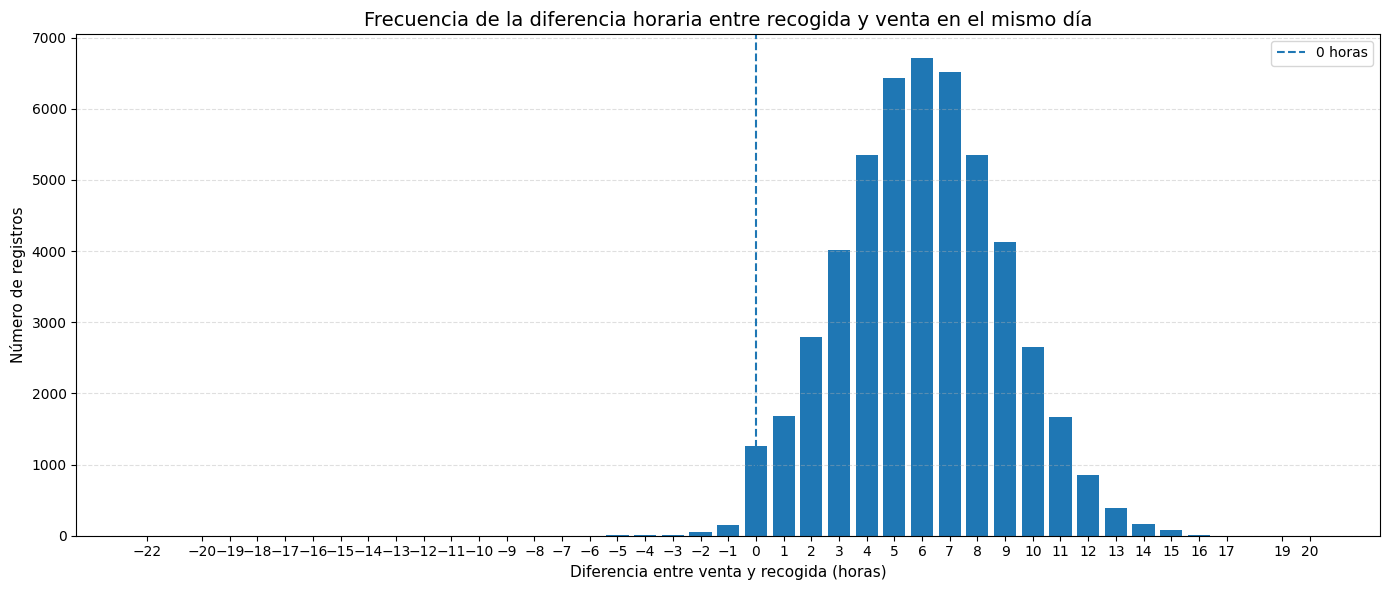

In [134]:
# ---------------------------------------------------------
# GRÁFICO DE FRECUENCIAS DE LA DIFERENCIA HORARIA
# ---------------------------------------------------------

# Calculamos la frecuencia de cada diferencia horaria
frecuencia_horas = (
    ventas_mismo_dia["diferencia_horas"]
    .value_counts()
    .sort_index()
)

# Gráfico horizontal / apaisado con barras verticales
plt.figure(figsize=(14, 6))

plt.bar(
    frecuencia_horas.index,
    frecuencia_horas.values,
    width=0.8
)

# Línea de referencia en 0 horas
plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1.5,
    label="0 horas"
)

plt.title(
    "Frecuencia de la diferencia horaria entre recogida y venta en el mismo día",
    fontsize=14
)

plt.xlabel(
    "Diferencia entre venta y recogida (horas)",
    fontsize=11
)

plt.ylabel(
    "Número de registros",
    fontsize=11
)

plt.xticks(
    frecuencia_horas.index,
    rotation=0
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.legend()

plt.tight_layout()
plt.show()

Se acumulan claramente las incidencias entre las 3-9 horas. Debido al número de incidencias: 50,348 no parece un error puntual o humano, parece más un error del sistema de trabajo o que se ha corrompido la entrada de datos de alguna forma.

Es muy probable que el sistema deje "fija" la hora de recogida y que el operario tenga que marcar la fecha de entrega de forma manual, dando lugar a esta cantidad de errores.

##Criterio 5

###Eliminamos cadenas de información con dos o más nulos

In [135]:
# ============================================================
# IDENTIFICACIÓN DE CADENAS CON 2 O MÁS VALORES NULOS
# ============================================================

# Unimos producto y venta para analizar toda la cadena
df_control_nulos = df_producto.merge(
    df_venta,
    on="id_producto",
    how="left"
).copy()


# Variables de negocio que forman la cadena de información
# No contamos los identificadores técnicos id_producto / id_venta
columnas_control_nulos = [
    "t_id",
    "id_tipo",
    "id_subtipo",
    "id_marca",
    "id_proveedor",
    "id_lote",
    "coste_inicial",
    "tiempo_recogida",
    "id_cliente",
    "precio_venta",
    "tiempo_venta",
    "peso"
]


# Contamos los nulos presentes en cada cadena
df_control_nulos["numero_nulos"] = (
    df_control_nulos[columnas_control_nulos]
    .isna()
    .sum(axis=1)
)


# ============================================================
# ID_PRODUCTO ELIMINADOS
# ============================================================

df_id_producto_eliminado = (
    df_control_nulos.loc[
        df_control_nulos["numero_nulos"] >= 2,
        ["id_producto"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)


# ============================================================
# ID_PRODUCTO LIMPIOS
# ============================================================

df_id_producto_limpio = (
    df_producto.loc[
        ~df_producto["id_producto"].isin(
            df_id_producto_eliminado["id_producto"]
        ),
        ["id_producto"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)


# ============================================================
# COMPROBACIÓN
# ============================================================

print(
    f"Productos originales: "
    f"{df_producto['id_producto'].nunique():,}"
)

print(
    f"Productos limpios: "
    f"{len(df_id_producto_limpio):,}"
)

print(
    f"Productos eliminados: "
    f"{len(df_id_producto_eliminado):,}"
)

print(
    f"Comprobación: "
    f"{len(df_id_producto_limpio) + len(df_id_producto_eliminado):,}"
)

Productos originales: 70,549
Productos limpios: 70,522
Productos eliminados: 27
Comprobación: 70,549


In [136]:
print("id_producto_limpio")
display(df_id_producto_limpio.head())

print("id_producto_eliminado")
display(df_id_producto_eliminado.head())

id_producto_limpio


,id_producto
0,1
1,2
2,3
3,4
4,5


id_producto_eliminado


,id_producto
0,250
1,4023
2,4283
3,6918
4,7389


###Eliminamos tiempos de venta nulos o 0
Considerando que son entregas no realizadas o extraviadas.

In [137]:
# ============================================================
# ANÁLISIS DE FECHAS AUSENTES O NO VÁLIDAS
# ============================================================

df_control_fechas = df_venta.merge(
    df_producto[
        [
            "id_producto",
            "tiempo_recogida"
        ]
    ],
    on="id_producto",
    how="left"
).copy()


# Conversión a datetime
df_control_fechas["tiempo_recogida_dt"] = pd.to_datetime(
    df_control_fechas["tiempo_recogida"],
    errors="coerce"
)

df_control_fechas["tiempo_venta_dt"] = pd.to_datetime(
    df_control_fechas["tiempo_venta"],
    errors="coerce"
)


# Identificación individual
sin_tiempo_recogida = (
    df_control_fechas["tiempo_recogida_dt"].isna()
)

sin_tiempo_venta = (
    df_control_fechas["tiempo_venta_dt"].isna()
)


print(
    f"Sin tiempo de recogida válido: "
    f"{sin_tiempo_recogida.sum():,}"
)

print(
    f"Sin tiempo de venta válido: "
    f"{sin_tiempo_venta.sum():,}"
)

print(
    f"Sin ambos tiempos: "
    f"{(sin_tiempo_recogida & sin_tiempo_venta).sum():,}"
)

Sin tiempo de recogida válido: 0
Sin tiempo de venta válido: 223
Sin ambos tiempos: 0


No existen ventas sin tiempo de recogida, por lo que el supuesto de que son ventas no completadas o pedidos perdidos cobra fuerza.

In [138]:
# ============================================================
# ELIMINAR CADENAS SIN TIEMPO DE VENTA VÁLIDO
# ============================================================

# ------------------------------------------------------------
# Identificamos los id_producto cuyo tiempo_venta
# es NULL o no puede interpretarse como fecha
# ------------------------------------------------------------

ids_sin_tiempo_venta = (
    df_venta.loc[
        pd.to_datetime(
            df_venta["tiempo_venta"],
            errors="coerce"
        ).isna(),
        "id_producto"
    ]
    .dropna()
    .drop_duplicates()
)


# ------------------------------------------------------------
# Comprobamos cuántos ya estaban eliminados
# por criterios anteriores
# ------------------------------------------------------------

ids_ya_eliminados = set(
    df_id_producto_eliminado["id_producto"]
)

ids_sin_tiempo_venta_set = set(
    ids_sin_tiempo_venta
)

ids_solapados = (
    ids_sin_tiempo_venta_set
    &
    ids_ya_eliminados
)

ids_nuevos_eliminados = (
    ids_sin_tiempo_venta_set
    -
    ids_ya_eliminados
)


print(
    f"Cadenas sin tiempo_venta válido: "
    f"{len(ids_sin_tiempo_venta_set):,}"
)

print(
    f"Ya eliminadas por criterios anteriores: "
    f"{len(ids_solapados):,}"
)

print(
    f"Nuevas cadenas eliminadas por este criterio: "
    f"{len(ids_nuevos_eliminados):,}"
)


# ------------------------------------------------------------
# Añadimos los nuevos id_producto al dataframe de eliminados
# ------------------------------------------------------------

df_id_producto_eliminado = (
    pd.concat(
        [
            df_id_producto_eliminado,
            pd.DataFrame({
                "id_producto": list(
                    ids_sin_tiempo_venta_set
                )
            })
        ],
        ignore_index=True
    )
    .drop_duplicates(subset="id_producto")
    .sort_values("id_producto")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Reconstruimos la lista de productos supervivientes
# ------------------------------------------------------------

df_id_producto_limpio = (
    df_producto.loc[
        ~df_producto["id_producto"].isin(
            df_id_producto_eliminado["id_producto"]
        ),
        ["id_producto"]
    ]
    .drop_duplicates()
    .sort_values("id_producto")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Comprobación
# ------------------------------------------------------------

print("\n--- RESULTADO ACUMULADO ---")

print(
    f"Productos originales: "
    f"{df_producto['id_producto'].nunique():,}"
)

print(
    f"Productos eliminados acumulados: "
    f"{len(df_id_producto_eliminado):,}"
)

print(
    f"Productos limpios restantes: "
    f"{len(df_id_producto_limpio):,}"
)

print(
    f"Comprobación total: "
    f"{len(df_id_producto_eliminado) + len(df_id_producto_limpio):,}"
)

Cadenas sin tiempo_venta válido: 223
Ya eliminadas por criterios anteriores: 5
Nuevas cadenas eliminadas por este criterio: 218

--- RESULTADO ACUMULADO ---
Productos originales: 70,549
Productos eliminados acumulados: 245
Productos limpios restantes: 70,304
Comprobación total: 70,549


###Análisis pesos nulos. ¿Devoluciones o errores?

In [139]:
# ============================================================
# ANÁLISIS DE PESOS NEGATIVOS
# ¿Errores independientes o posibles devoluciones?
# ============================================================

df_pesos = df_venta.merge(
    df_producto[
        [
            "id_producto",
            "t_id",
            "id_tipo",
            "id_subtipo",
            "id_proveedor",
            "id_lote",
            "coste_inicial",
            "tiempo_recogida"
        ]
    ],
    on="id_producto",
    how="left"
).copy()

df_pesos["peso_negativo"] = df_pesos["peso"] < 0

print(f"Registros totales: {len(df_pesos):,}")
print(
    f"Pesos negativos: "
    f"{df_pesos['peso_negativo'].sum():,}"
)
print(
    f"Porcentaje: "
    f"{df_pesos['peso_negativo'].mean() * 100:.3f} %"
)

Registros totales: 70,549
Pesos negativos: 113
Porcentaje: 0.160 %


In [140]:
# ============================================================
# COMPARACIÓN DE LAS DISTRIBUCIONES
# ============================================================

resumen_pesos = (
    df_pesos
    .groupby("peso_negativo")
    .agg(
        registros=("id_producto", "count"),

        peso_medio=("peso", "mean"),
        peso_mediana=("peso", "median"),

        # Mínimo y máximo según magnitud del peso
        peso_abs_minimo=("peso", lambda x: x.abs().min()),
        peso_abs_maximo=("peso", lambda x: x.abs().max()),

        precio_medio=("precio_venta", "mean"),
        coste_medio=("coste_inicial", "mean"),

        clientes=("id_cliente", "nunique"),
        tipos=("id_tipo", "nunique"),
        proveedores=("id_proveedor", "nunique")
    )
)

display(resumen_pesos)

,registros,peso_medio,peso_mediana,peso_abs_minimo,peso_abs_maximo,precio_medio,coste_medio,clientes,tipos,proveedores
peso_negativo,,,,,,,,,,
False,70436,300.773071,300.463302,0.20669,706.148708,3.498966,1.999998,34,15,35
True,113,-30.796453,-25.410905,0.40105,101.598110,3.461775,1.975775,34,15,32


Supongamos que las devoluciones deben ser de un mismo lote y cliente para que la empresa tenga una trazabilidad, entendiendo que la fruta al ser perecedera no se puede devolver si no se hace en el momento que se entrega.

In [141]:
# ============================================================
# ¿EXISTE UNA VENTA POSITIVA DEL MISMO LOTE AL MISMO CLIENTE?
# ============================================================

df_negativos = df_pesos[
    df_pesos["peso"] < 0
].copy()

df_positivos = df_pesos[
    df_pesos["peso"] >= 0
].copy()

# Combinaciones lote-cliente donde existe una venta positiva
pares_positivos = (
    df_positivos[
        ["id_lote", "id_cliente"]
    ]
    .drop_duplicates()
)

# Comprobamos si los negativos tienen un equivalente
# positivo para ese mismo lote y cliente
df_negativos_devolucion = df_negativos.merge(
    pares_positivos.assign(
        existe_venta_positiva_mismo_lote_cliente=True
    ),
    on=["id_lote", "id_cliente"],
    how="left"
)

df_negativos_devolucion[
    "existe_venta_positiva_mismo_lote_cliente"
] = (
    df_negativos_devolucion[
        "existe_venta_positiva_mismo_lote_cliente"
    ]
    .fillna(False)
)

display(
    df_negativos_devolucion[
        "existe_venta_positiva_mismo_lote_cliente"
    ]
    .value_counts()
)

/tmp/ipykernel_4888/3419894191.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,count
existe_venta_positiva_mismo_lote_cliente,
False,113


¿Existe alguna concentración específica de los importes negativos?

In [142]:
# ============================================================
# DISTRIBUCIÓN DE PESOS NEGATIVOS POR VARIABLES DE NEGOCIO
# ============================================================

def resumen_negativos_por(variable):

    resumen = (
        df_pesos
        .groupby(variable)
        .agg(
            registros=("id_producto", "count"),
            negativos=(
                "peso",
                lambda x: (x < 0).sum()
            )
        )
    )

    resumen["porcentaje_negativos"] = (
        resumen["negativos"]
        / resumen["registros"]
        * 100
    )

    return resumen.sort_values(
        "porcentaje_negativos",
        ascending=False
    )


display(resumen_negativos_por("id_cliente"))
display(resumen_negativos_por("id_tipo"))
display(resumen_negativos_por("id_proveedor"))

,registros,negativos,porcentaje_negativos
id_cliente,,,
13,2034,6,0.294985
1,2090,6,0.287081
26,2115,6,0.283688
4,2029,5,0.246427
18,2038,5,0.245339
7,2051,5,0.243784
15,2086,5,0.239693
21,2094,5,0.238777
10,2104,5,0.237643


,registros,negativos,porcentaje_negativos
id_tipo,,,
3,2080,5,0.240385
9,3012,7,0.232404
13,2167,5,0.230734
11,2501,5,0.199920
7,3012,6,0.199203
2,3027,6,0.198216
5,8465,15,0.177200
4,19698,32,0.162453
8,2629,4,0.152149


,registros,negativos,porcentaje_negativos
id_proveedor,,,
17,2012,9,0.447316
30,1979,7,0.353714
8,2039,7,0.343306
1,2060,7,0.339806
13,2030,6,0.295567
6,2077,6,0.288878
15,1958,5,0.255363
27,2011,5,0.248633
10,2021,5,0.247402


¿Y comparado con la distribución de los pesos?

In [143]:
# ============================================================
# ¿SON LOS NEGATIVOS COMPATIBLES CON LA COLA DE
# UNA DISTRIBUCIÓN NORMAL DE LOS PESOS?
# ============================================================

from scipy.stats import norm

pesos_positivos = df_pesos.loc[
    df_pesos["peso"] >= 0,
    "peso"
]

media = pesos_positivos.mean()
desviacion = pesos_positivos.std()

# Probabilidad teórica de obtener un valor < 0
probabilidad_negativo = norm.cdf(
    0,
    loc=media,
    scale=desviacion
)

negativos_esperados = (
    probabilidad_negativo
    * len(df_pesos)
)

print(f"Media pesos positivos: {media:.2f} g")
print(f"Desviación estándar: {desviacion:.2f} g")

print(
    f"Pesos negativos observados: "
    f"{(df_pesos['peso'] < 0).sum()}"
)

print(
    f"Pesos negativos esperados bajo una normal: "
    f"{negativos_esperados:.2f}"
)

print(
    f"Media de los pesos negativos observados: "
    f"{df_pesos.loc[df_pesos['peso'] < 0, 'peso'].mean():.2f} g"
)

Media pesos positivos: 300.77 g
Desviación estándar: 99.17 g
Pesos negativos observados: 113
Pesos negativos esperados bajo una normal: 85.42
Media de los pesos negativos observados: -30.80 g


Conclusión: parece nuevamente un error en la introducción del dato al sistema  o un error en los sistemas de pesaje (errores de tara o de sistema de pesaje)

Añadimos los nuevos id_productos a la lista de eliminados, puede haber duplicados con aquellos que tenían más de un nulo en su cadena de información.

In [144]:
# ============================================================
# ELIMINACIÓN DE CADENAS CON PESO NEGATIVO
# ============================================================

# Identificamos los id_producto afectados por pesos negativos
ids_peso_negativo = (
    df_venta.loc[
        df_venta["peso"] < 0,
        "id_producto"
    ]
    .dropna()
    .drop_duplicates()
)

# Número de cadenas detectadas por este criterio
print(
    f"Cadenas con peso negativo detectadas: "
    f"{len(ids_peso_negativo):,}"
)


# ------------------------------------------------------------
# Comprobamos cuántas ya estaban eliminadas por criterios previos
# ------------------------------------------------------------

ids_ya_eliminados = set(
    df_id_producto_eliminado["id_producto"]
)

ids_nuevos_peso_negativo = set(ids_peso_negativo) - ids_ya_eliminados

print(
    f"Ya eliminadas por criterios anteriores: "
    f"{len(set(ids_peso_negativo) & ids_ya_eliminados):,}"
)

print(
    f"Nuevas cadenas eliminadas por peso negativo: "
    f"{len(ids_nuevos_peso_negativo):,}"
)


# ------------------------------------------------------------
# Añadimos los id_producto al dataframe de eliminados
# ------------------------------------------------------------

df_id_producto_eliminado = (
    pd.concat(
        [
            df_id_producto_eliminado,
            pd.DataFrame({
                "id_producto": ids_peso_negativo
            })
        ],
        ignore_index=True
    )
    .drop_duplicates(subset="id_producto")
    .sort_values("id_producto")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Reconstruimos el dataframe de productos limpios
# ------------------------------------------------------------

df_id_producto_limpio = (
    df_producto.loc[
        ~df_producto["id_producto"].isin(
            df_id_producto_eliminado["id_producto"]
        ),
        ["id_producto"]
    ]
    .drop_duplicates()
    .sort_values("id_producto")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Comprobación
# ------------------------------------------------------------

print("\n--- RESULTADO ACUMULADO ---")

print(
    f"Productos originales: "
    f"{df_producto['id_producto'].nunique():,}"
)

print(
    f"Productos eliminados acumulados: "
    f"{len(df_id_producto_eliminado):,}"
)

print(
    f"Productos limpios restantes: "
    f"{len(df_id_producto_limpio):,}"
)

print(
    f"Comprobación total: "
    f"{len(df_id_producto_eliminado) + len(df_id_producto_limpio):,}"
)

Cadenas con peso negativo detectadas: 113
Ya eliminadas por criterios anteriores: 0
Nuevas cadenas eliminadas por peso negativo: 113

--- RESULTADO ACUMULADO ---
Productos originales: 70,549
Productos eliminados acumulados: 358
Productos limpios restantes: 70,191
Comprobación total: 70,549


###Arreglamos un único nulo en coste_inicial o precio_venta
Criterio: usamos una media por operación no por día de las transacciones del tipo de fruta de ±1 día con respecto al evento: recogida para coste, venta para precio.

In [145]:
# ============================================================
# TABAJAMOS SOBRE PRODUCTOS SUPERVIVIENTES A LOS NULOS
# ============================================================

ids_limpios = set(
    df_id_producto_limpio["id_producto"]
)

# Producto: solo cadenas supervivientes
df_producto_superviviente = (
    df_producto[
        df_producto["id_producto"].isin(ids_limpios)
    ]
    .copy()
)

# Venta: solo cadenas supervivientes
df_venta_superviviente = (
    df_venta[
        df_venta["id_producto"].isin(ids_limpios)
    ]
    .copy()
)

# Añadimos id_tipo a venta para poder calcular
# la media por TIPO de fruta, no por subtipo
df_venta_superviviente = df_venta_superviviente.merge(
    df_producto_superviviente[
        [
            "id_producto",
            "id_tipo"
        ]
    ],
    on="id_producto",
    how="left",
    validate="many_to_one"
)

# Fechas normalizadas
df_producto_superviviente["fecha_recogida"] = (
    pd.to_datetime(
        df_producto_superviviente["tiempo_recogida"],
        errors="coerce"
    )
    .dt.normalize()
)

df_venta_superviviente["fecha_venta"] = (
    pd.to_datetime(
        df_venta_superviviente["tiempo_venta"],
        errors="coerce"
    )
    .dt.normalize()
)

Cálculo de las medias

In [146]:
# ============================================================
# FUNCIÓN:
# Media por tipo de fruta en una ventana de 3 días
# día anterior + mismo día + día posterior
# ============================================================

def calcular_media_ventana_3_dias(
    df,
    columna_valor,
    columna_fecha
):

    # --------------------------------------------------------
    # 1. Registros válidos que pueden actuar como referencia
    # --------------------------------------------------------
    # Excluimos NULL y 0 del cálculo de las medias.

    df_validos = df[
        df[columna_valor].notna()
        &
        (df[columna_valor] != 0)
        &
        df[columna_fecha].notna()
        &
        df["id_tipo"].notna()
    ].copy()


    # --------------------------------------------------------
    # 2. Suma y nº de observaciones por tipo y día
    # --------------------------------------------------------

    resumen_diario = (
        df_validos
        .groupby(
            [
                "id_tipo",
                columna_fecha
            ]
        )[columna_valor]
        .agg(
            suma="sum",
            registros="count"
        )
        .reset_index()
    )


    # --------------------------------------------------------
    # 3. Cada día aporta información a tres días objetivo:
    #    día anterior, mismo día y día posterior
    # --------------------------------------------------------

    ventanas = []

    for desplazamiento in [-1, 0, 1]:

        temporal = resumen_diario.copy()

        temporal["fecha_objetivo"] = (
            temporal[columna_fecha]
            + pd.Timedelta(days=desplazamiento)
        )

        ventanas.append(temporal)


    ventana_tres_dias = pd.concat(
        ventanas,
        ignore_index=True
    )


    # --------------------------------------------------------
    # 4. Media conjunta de todas las observaciones
    #    de los tres días
    # --------------------------------------------------------

    ventana_tres_dias = (
        ventana_tres_dias
        .groupby(
            [
                "id_tipo",
                "fecha_objetivo"
            ],
            as_index=False
        )
        .agg(
            suma=("suma", "sum"),
            registros=("registros", "sum")
        )
    )

    ventana_tres_dias["media_3_dias"] = (
        ventana_tres_dias["suma"]
        /
        ventana_tres_dias["registros"]
    )

    return ventana_tres_dias

Coste_inicial

In [147]:
# ============================================================
# NUEVOS COSTES INICIALES
# ============================================================

# Calculamos las medias móviles de 3 días
medias_coste_3_dias = calcular_media_ventana_3_dias(
    df=df_producto_superviviente,
    columna_valor="coste_inicial",
    columna_fecha="fecha_recogida"
)


# ------------------------------------------------------------
# Productos supervivientes que necesitan nuevo coste
# ------------------------------------------------------------

objetivos_coste = (
    df_producto_superviviente[
        df_producto_superviviente["coste_inicial"].isna()
        |
        (df_producto_superviviente["coste_inicial"] == 0)
    ][
        [
            "id_producto",
            "id_tipo",
            "fecha_recogida"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Asignamos la media correspondiente
# ------------------------------------------------------------

df_costes_nuevos = (
    objetivos_coste
    .merge(
        medias_coste_3_dias[
            [
                "id_tipo",
                "fecha_objetivo",
                "media_3_dias"
            ]
        ],
        left_on=[
            "id_tipo",
            "fecha_recogida"
        ],
        right_on=[
            "id_tipo",
            "fecha_objetivo"
        ],
        how="left"
    )
    [
        [
            "id_producto",
            "media_3_dias"
        ]
    ]
    .rename(
        columns={
            "media_3_dias": "coste_inicial"
        }
    )
    .sort_values("id_producto")
    .reset_index(drop=True)
)

display(df_costes_nuevos)

,id_producto,coste_inicial
0,42,1.989936
1,101,1.978253
2,124,2.000045
3,206,2.001588
4,224,2.005593
...,...,...
1976,70346,2.047074
1977,70397,2.013978
1978,70495,1.964258
1979,70510,1.969918


Precios_venta

In [148]:
# ============================================================
# NUEVOS PRECIOS DE VENTA
# ============================================================

# Calculamos las medias de los tres días
medias_precio_3_dias = calcular_media_ventana_3_dias(
    df=df_venta_superviviente,
    columna_valor="precio_venta",
    columna_fecha="fecha_venta"
)


# ------------------------------------------------------------
# Productos supervivientes que necesitan nuevo precio
# ------------------------------------------------------------

objetivos_precio = (
    df_venta_superviviente[
        df_venta_superviviente["precio_venta"].isna()
        |
        (df_venta_superviviente["precio_venta"] == 0)
    ][
        [
            "id_producto",
            "id_tipo",
            "fecha_venta"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Asignamos la media correspondiente
# ------------------------------------------------------------

df_precios_nuevos = (
    objetivos_precio
    .merge(
        medias_precio_3_dias[
            [
                "id_tipo",
                "fecha_objetivo",
                "media_3_dias"
            ]
        ],
        left_on=[
            "id_tipo",
            "fecha_venta"
        ],
        right_on=[
            "id_tipo",
            "fecha_objetivo"
        ],
        how="left"
    )
    [
        [
            "id_producto",
            "media_3_dias"
        ]
    ]
    .rename(
        columns={
            "media_3_dias": "precio_venta"
        }
    )
    .sort_values("id_producto")
    .reset_index(drop=True)
)

display(df_precios_nuevos)

,id_producto,precio_venta
0,21,3.483597
1,147,3.465792
2,148,3.512475
3,166,3.480960
4,306,3.480960
...,...,...
664,69999,3.392461
665,70231,3.482401
666,70352,3.531212
667,70358,3.462186


Comprobamos valores huérfanos

In [149]:
# ============================================================
# COMPROBACIÓN DE IMPUTACIONES
# ============================================================

print("COSTE INICIAL")
print(
    f"Valores a sustituir: "
    f"{len(df_costes_nuevos):,}"
)
print(
    f"Valores calculados: "
    f"{df_costes_nuevos['coste_inicial'].notna().sum():,}"
)
print(
    f"Sin media disponible: "
    f"{df_costes_nuevos['coste_inicial'].isna().sum():,}"
)


print("\nPRECIO DE VENTA")
print(
    f"Valores a sustituir: "
    f"{len(df_precios_nuevos):,}"
)
print(
    f"Valores calculados: "
    f"{df_precios_nuevos['precio_venta'].notna().sum():,}"
)
print(
    f"Sin media disponible: "
    f"{df_precios_nuevos['precio_venta'].isna().sum():,}"
)

COSTE INICIAL
Valores a sustituir: 1,981
Valores calculados: 1,981
Sin media disponible: 0

PRECIO DE VENTA
Valores a sustituir: 669
Valores calculados: 669
Sin media disponible: 0


Los valores corregidos tienen sentido con los analizados en el 5º Criterio y no deja huérfanos.

In [150]:
display(df_costes_nuevos.head(20))
display(df_precios_nuevos.head(20))

,id_producto,coste_inicial
0,42,1.989936
1,101,1.978253
2,124,2.000045
3,206,2.001588
4,224,2.005593
5,228,2.009019
6,262,2.011937
7,282,2.019774
8,295,2.004048
9,478,1.987703


,id_producto,precio_venta
0,21,3.483597
1,147,3.465792
2,148,3.512475
3,166,3.480960
4,306,3.480960
5,327,3.505617
6,789,3.480960
7,807,3.435935
8,1118,3.461543
9,1126,3.467286


###Tiempos de venta con incidencias con tiempos de recogida

In [151]:
# ============================================================
# NUEVOS TIEMPOS DE VENTA
# Conservamos la hora original de venta
# ============================================================

# ------------------------------------------------------------
# 1. Trabajamos solo con productos supervivientes
# ------------------------------------------------------------

ids_limpios = set(
    df_id_producto_limpio["id_producto"]
)

df_control_tiempo_venta = (
    df_venta[
        df_venta["id_producto"].isin(ids_limpios)
    ]
    .merge(
        df_producto[
            df_producto["id_producto"].isin(ids_limpios)
        ][
            [
                "id_producto",
                "tiempo_recogida"
            ]
        ],
        on="id_producto",
        how="left"
    )
    .copy()
)


# ------------------------------------------------------------
# 2. Conversión a datetime
# ------------------------------------------------------------

df_control_tiempo_venta["tiempo_recogida"] = pd.to_datetime(
    df_control_tiempo_venta["tiempo_recogida"],
    errors="coerce"
)

df_control_tiempo_venta["tiempo_venta"] = pd.to_datetime(
    df_control_tiempo_venta["tiempo_venta"],
    errors="coerce"
)


# ------------------------------------------------------------
# 3. Obtenemos el día natural de recogida y venta
# ------------------------------------------------------------

df_control_tiempo_venta["fecha_recogida"] = (
    df_control_tiempo_venta["tiempo_recogida"]
    .dt.normalize()
)

df_control_tiempo_venta["fecha_venta"] = (
    df_control_tiempo_venta["tiempo_venta"]
    .dt.normalize()
)


# ------------------------------------------------------------
# 4. Identificamos las ventas a corregir
# ------------------------------------------------------------
# - Venta en día anterior a la recogida
# - Venta el mismo día que la recogida

condicion_corregir = (
    df_control_tiempo_venta["fecha_recogida"].notna()
    &
    df_control_tiempo_venta["fecha_venta"].notna()
    &
    (
        df_control_tiempo_venta["fecha_venta"]
        <=
        df_control_tiempo_venta["fecha_recogida"]
    )
)


# ------------------------------------------------------------
# 5. Creamos df_tiempo_venta_nuevos
# ------------------------------------------------------------

df_tiempo_venta_nuevos = (
    df_control_tiempo_venta.loc[
        condicion_corregir,
        [
            "id_producto",
            "tiempo_recogida",
            "tiempo_venta"
        ]
    ]
    .copy()
)


# Extraemos únicamente la hora original de venta
hora_original_venta = (
    df_tiempo_venta_nuevos["tiempo_venta"]
    -
    df_tiempo_venta_nuevos["tiempo_venta"].dt.normalize()
)


# Nueva fecha:
# día siguiente a la recogida + hora original de venta
df_tiempo_venta_nuevos["tiempo_venta_nuevo"] = (
    df_tiempo_venta_nuevos["tiempo_recogida"].dt.normalize()
    + pd.Timedelta(days=1)
    + hora_original_venta
)


# Conservamos únicamente las columnas necesarias
df_tiempo_venta_nuevos = (
    df_tiempo_venta_nuevos[
        [
            "id_producto",
            "tiempo_venta_nuevo"
        ]
    ]
    .rename(
        columns={
            "tiempo_venta_nuevo": "tiempo_venta"
        }
    )
    .sort_values("id_producto")
    .reset_index(drop=True)
)

display(df_tiempo_venta_nuevos)

,id_producto,tiempo_venta
0,1,2025-09-20 12:00:00
1,3,2025-09-20 22:00:00
2,4,2025-09-29 17:00:00
3,6,2025-09-09 23:00:00
4,7,2025-09-20 17:00:00
...,...,...
51146,70544,2025-09-04 14:00:00
51147,70546,2025-09-20 08:00:00
51148,70547,2025-09-20 13:00:00
51149,70548,2025-09-23 07:00:00


In [152]:
# ============================================================
# COMPROBACIÓN QUE MANTIENE LA HORA Y CAMBIA DIA
# ============================================================

df_comprobacion_tiempo = (
    df_control_tiempo_venta.loc[
        condicion_corregir,
        [
            "id_producto",
            "tiempo_recogida",
            "tiempo_venta"
        ]
    ]
    .merge(
        df_tiempo_venta_nuevos,
        on="id_producto",
        how="left",
        suffixes=("_original", "_nuevo")
    )
)

df_comprobacion_tiempo["hora_conservada"] = (
    df_comprobacion_tiempo["tiempo_venta_original"].dt.time
    ==
    df_comprobacion_tiempo["tiempo_venta_nuevo"].dt.time
)

df_comprobacion_tiempo["dias_desde_recogida"] = (
    df_comprobacion_tiempo["tiempo_venta_nuevo"].dt.normalize()
    -
    df_comprobacion_tiempo["tiempo_recogida"].dt.normalize()
).dt.days

print("Horas conservadas:")
display(
    df_comprobacion_tiempo["hora_conservada"]
    .value_counts()
)

print("\nDiferencia de días tras la corrección:")
display(
    df_comprobacion_tiempo["dias_desde_recogida"]
    .value_counts()
    .sort_index()
)

Horas conservadas:


,count
hora_conservada,
True,51151



Diferencia de días tras la corrección:


,count
dias_desde_recogida,
1,51151


In [153]:
# ============================================================
# RESUMEN DE CORRECCIONES
# ============================================================

venta_anterior = (
    df_control_tiempo_venta["fecha_venta"]
    <
    df_control_tiempo_venta["fecha_recogida"]
)

venta_mismo_dia = (
    df_control_tiempo_venta["fecha_venta"]
    ==
    df_control_tiempo_venta["fecha_recogida"]
)

print(
    f"Ventas en día anterior a la recogida: "
    f"{venta_anterior.sum():,}"
)

print(
    f"Ventas el mismo día que la recogida: "
    f"{venta_mismo_dia.sum():,}"
)

print(
    f"Total de tiempos de venta a sustituir: "
    f"{len(df_tiempo_venta_nuevos):,}"
)

Ventas en día anterior a la recogida: 905
Ventas el mismo día que la recogida: 50,246
Total de tiempos de venta a sustituir: 51,151


##Post Criterio 5 NUEVA BBDD

In [154]:
# ============================================================
# CONSTRUCCIÓN DE LA NUEVA BBDD LIMPIA
# ============================================================

# Conjunto de productos que han sobrevivido a los criterios
ids_limpios = set(
    df_id_producto_limpio["id_producto"]
)


# ============================================================
# 1. PRODUCTO
# ============================================================

df_producto_BBDD = (
    df_producto[
        df_producto["id_producto"].isin(ids_limpios)
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 2. VENTA
# ============================================================

df_venta_BBDD = (
    df_venta[
        df_venta["id_producto"].isin(ids_limpios)
    ]
    .copy()
    .reset_index(drop=True)
)

In [155]:
# ============================================================
# APLICAR NUEVOS COSTES
# ============================================================

if df_costes_nuevos["id_producto"].duplicated().any():
    raise ValueError(
        "Existen id_producto duplicados en df_costes_nuevos"
    )

mapa_costes = (
    df_costes_nuevos
    .set_index("id_producto")["coste_inicial"]
)

mascara_costes = (
    df_producto_BBDD["id_producto"]
    .isin(mapa_costes.index)
)

df_producto_BBDD.loc[
    mascara_costes,
    "coste_inicial"
] = (
    df_producto_BBDD.loc[
        mascara_costes,
        "id_producto"
    ]
    .map(mapa_costes)
)

In [156]:
# ============================================================
# APLICAR NUEVOS PRECIOS DE VENTA
# ============================================================

if df_precios_nuevos["id_producto"].duplicated().any():
    raise ValueError(
        "Existen id_producto duplicados en df_precios_nuevos"
    )

mapa_precios = (
    df_precios_nuevos
    .set_index("id_producto")["precio_venta"]
)

mascara_precios = (
    df_venta_BBDD["id_producto"]
    .isin(mapa_precios.index)
)

df_venta_BBDD.loc[
    mascara_precios,
    "precio_venta"
] = (
    df_venta_BBDD.loc[
        mascara_precios,
        "id_producto"
    ]
    .map(mapa_precios)
)

Los tiempos de venta han dado error la primera vez por no convertir a datetime el dato.

In [157]:
# ============================================================
# APLICAR NUEVOS TIEMPOS DE VENTA
# ============================================================

# Comprobamos que cada id_producto tenga una única corrección
if df_tiempo_venta_nuevos["id_producto"].duplicated().any():
    raise ValueError(
        "Existen id_producto duplicados en "
        "df_tiempo_venta_nuevos"
    )


# ------------------------------------------------------------
# Aseguramos formato datetime
# ------------------------------------------------------------

df_venta_BBDD["tiempo_venta"] = pd.to_datetime(
    df_venta_BBDD["tiempo_venta"],
    errors="coerce"
)

df_tiempo_venta_nuevos["tiempo_venta"] = pd.to_datetime(
    df_tiempo_venta_nuevos["tiempo_venta"],
    errors="coerce"
)


# ------------------------------------------------------------
# Creamos mapa id_producto -> nuevo tiempo_venta
# ------------------------------------------------------------

mapa_tiempos = (
    df_tiempo_venta_nuevos
    .set_index("id_producto")["tiempo_venta"]
)


# ------------------------------------------------------------
# Identificamos los registros que deben corregirse
# ------------------------------------------------------------

mascara_tiempos = (
    df_venta_BBDD["id_producto"]
    .isin(mapa_tiempos.index)
)


# ------------------------------------------------------------
# Obtenemos los nuevos valores
# ------------------------------------------------------------

nuevos_tiempos = (
    df_venta_BBDD.loc[
        mascara_tiempos,
        "id_producto"
    ]
    .map(mapa_tiempos)
)


# ------------------------------------------------------------
# Aplicamos la sustitución
# ------------------------------------------------------------
# Utilizamos to_numpy() para realizar la asignación por posición
# y evitar cualquier posible problema de alineación de índices.

df_venta_BBDD.loc[
    mascara_tiempos,
    "tiempo_venta"
] = nuevos_tiempos.to_numpy()


# ------------------------------------------------------------
# COMPROBACIÓN
# ------------------------------------------------------------

print(
    f"Tiempos de venta que debían corregirse: "
    f"{len(df_tiempo_venta_nuevos):,}"
)

print(
    f"Tiempos de venta aplicados en df_venta_BBDD: "
    f"{mascara_tiempos.sum():,}"
)

# Comprobamos que el valor almacenado en la BBDD
# coincide con el valor calculado
comprobacion = (
    df_venta_BBDD.loc[
        mascara_tiempos,
        ["id_producto", "tiempo_venta"]
    ]
    .merge(
        df_tiempo_venta_nuevos,
        on="id_producto",
        how="left",
        suffixes=("_BBDD", "_nuevo"),
        validate="one_to_one"
    )
)

coinciden = (
    comprobacion["tiempo_venta_BBDD"]
    ==
    comprobacion["tiempo_venta_nuevo"]
)

print(
    f"Correcciones verificadas correctamente: "
    f"{coinciden.sum():,} de {len(comprobacion):,}"
)

print(
    f"Correcciones incorrectas: "
    f"{(~coinciden).sum():,}"
)

Tiempos de venta que debían corregirse: 51,151
Tiempos de venta aplicados en df_venta_BBDD: 51,151
Correcciones verificadas correctamente: 51,151 de 51,151
Correcciones incorrectas: 0


No voy a limpiar las otras tablas que son de listados de categoría (marca, tipo, clientes...) porque no reduciremos el peso de la BBDD hago copias.

In [158]:
# ============================================================
# COPIA DE TABLAS MAESTRAS PARA LA NUEVA BBDD
# ============================================================
# Estas tablas no requieren limpieza.
# Se mantienen completas y se copian sin modificaciones.
# ============================================================

df_clientes_BBDD = df_clientes.copy()
df_lote_BBDD = df_lote.copy()
df_marca_BBDD = df_marca.copy()
df_proveedor_BBDD = df_proveedor.copy()
df_subtipo_BBDD = df_subtipo.copy()
df_tipo_BBDD = df_tipo.copy()

In [159]:
# ============================================================
# RESUMEN
# ============================================================

resumen_BBDD = pd.DataFrame({
    "tabla": [
        "producto",
        "venta",
        "clientes",
        "lote",
        "marca",
        "proveedor",
        "subtipo",
        "tipo"
    ],
    "original": [
        len(df_producto),
        len(df_venta),
        len(df_clientes),
        len(df_lote),
        len(df_marca),
        len(df_proveedor),
        len(df_subtipo),
        len(df_tipo)
    ],
    "BBDD": [
        len(df_producto_BBDD),
        len(df_venta_BBDD),
        len(df_clientes_BBDD),
        len(df_lote_BBDD),
        len(df_marca_BBDD),
        len(df_proveedor_BBDD),
        len(df_subtipo_BBDD),
        len(df_tipo_BBDD)
    ]
})

display(resumen_BBDD)

,tabla,original,BBDD
0,producto,70549,70191
1,venta,70549,70191
2,clientes,34,34
3,lote,69567,69567
4,marca,35,35
5,proveedor,35,35
6,subtipo,27,27
7,tipo,15,15


In [160]:
display(df_id_producto_eliminado)

,id_producto
0,250
1,404
2,1051
3,1622
4,2109
...,...
353,69739
354,69834
355,69932
356,69956


Sólo se han eliminado 140 líneas que son las cadenas con más de un nulo y los que tenían pesos negativos.

###Criterio 1

In [161]:
# ============================================================
# CRITERIO 1
# La venta debe producirse en un día posterior
# al día de recogida
# ============================================================

df_criterio_1_BBDD = (
    df_venta_BBDD
    .merge(
        df_producto_BBDD[
            [
                "id_producto",
                "tiempo_recogida"
            ]
        ],
        on="id_producto",
        how="left"
    )
    .copy()
)


# ------------------------------------------------------------
# Conversión a datetime
# ------------------------------------------------------------

df_criterio_1_BBDD["tiempo_recogida"] = pd.to_datetime(
    df_criterio_1_BBDD["tiempo_recogida"],
    errors="coerce"
)

df_criterio_1_BBDD["tiempo_venta"] = pd.to_datetime(
    df_criterio_1_BBDD["tiempo_venta"],
    errors="coerce"
)


# ------------------------------------------------------------
# Obtenemos únicamente el día natural
# ------------------------------------------------------------

df_criterio_1_BBDD["fecha_recogida"] = (
    df_criterio_1_BBDD["tiempo_recogida"]
    .dt.normalize()
)

df_criterio_1_BBDD["fecha_venta"] = (
    df_criterio_1_BBDD["tiempo_venta"]
    .dt.normalize()
)


# ------------------------------------------------------------
# Clasificación
# ------------------------------------------------------------

condiciones = [
    (
        df_criterio_1_BBDD["fecha_recogida"].isna()
        |
        df_criterio_1_BBDD["fecha_venta"].isna()
    ),

    (
        df_criterio_1_BBDD["fecha_venta"]
        <
        df_criterio_1_BBDD["fecha_recogida"]
    ),

    (
        df_criterio_1_BBDD["fecha_venta"]
        ==
        df_criterio_1_BBDD["fecha_recogida"]
    )
]

resultados = [
    "Fecha ausente o no válida",
    "Venta anterior a la recogida",
    "Recogida y venta en el mismo día"
]

df_criterio_1_BBDD["error_criterio_1"] = np.select(
    condiciones,
    resultados,
    default=None
)


# ------------------------------------------------------------
# Registros que incumplen el criterio
# ------------------------------------------------------------

df_errores_criterio_1_BBDD = (
    df_criterio_1_BBDD[
        df_criterio_1_BBDD["error_criterio_1"].notna()
    ]
    .copy()
)


# ------------------------------------------------------------
# Resumen
# ------------------------------------------------------------

resumen_criterio_1_BBDD = (
    df_errores_criterio_1_BBDD[
        "error_criterio_1"
    ]
    .value_counts()
    .rename_axis("tipo_error")
    .reset_index(name="numero_registros")
)

display(resumen_criterio_1_BBDD)

,tipo_error,numero_registros


Como hemos resuelto o eliminado los errores temporales, todos los registros supervivientes cumplen este criterio.

In [162]:
# ============================================================
# COMPROBACIÓN FINAL DEL CRITERIO 1
# ============================================================

registros_totales = len(df_criterio_1_BBDD)

registros_validos = (
    df_criterio_1_BBDD["fecha_venta"]
    >
    df_criterio_1_BBDD["fecha_recogida"]
).sum()

registros_invalidos = len(
    df_errores_criterio_1_BBDD
)

print(
    f"Registros analizados: "
    f"{registros_totales:,}"
)

print(
    f"Registros que cumplen el criterio: "
    f"{registros_validos:,}"
)

print(
    f"Registros que incumplen el criterio: "
    f"{registros_invalidos:,}"
)

print(
    f"Porcentaje de cumplimiento: "
    f"{registros_validos / registros_totales * 100:.2f}%"
)

Registros analizados: 70,191
Registros que cumplen el criterio: 70,191
Registros que incumplen el criterio: 0
Porcentaje de cumplimiento: 100.00%


###Criterio 2
Anteriormente sobrevivían a este criterio todos registros de ventas.

In [163]:
# ============================================================
# CRITERIO 2
# Un proveedor no puede superar 100 kg (100.000 g)
# de un mismo tipo de fruta en un mismo día de recogida
# ============================================================

LIMITE_PESO_GRAMOS = 100_000


# ------------------------------------------------------------
# 1. Construimos los datos necesarios
# ------------------------------------------------------------

df_criterio_2_BBDD = (
    df_producto_BBDD[
        [
            "id_producto",
            "id_proveedor",
            "id_tipo",
            "tiempo_recogida"
        ]
    ]
    .merge(
        df_venta_BBDD[
            [
                "id_producto",
                "peso"
            ]
        ],
        on="id_producto",
        how="inner",
        validate="one_to_one"
    )
    .copy()
)


# ------------------------------------------------------------
# 2. Obtenemos el día natural de recogida
# ------------------------------------------------------------

df_criterio_2_BBDD["tiempo_recogida"] = pd.to_datetime(
    df_criterio_2_BBDD["tiempo_recogida"],
    errors="coerce"
)

df_criterio_2_BBDD["fecha_recogida"] = (
    df_criterio_2_BBDD["tiempo_recogida"]
    .dt.normalize()
)


# ------------------------------------------------------------
# 3. Sumamos el peso por:
#    proveedor + tipo de fruta + día
# ------------------------------------------------------------

resumen_criterio_2_BBDD = (
    df_criterio_2_BBDD
    .groupby(
        [
            "id_proveedor",
            "id_tipo",
            "fecha_recogida"
        ],
        as_index=False
    )
    .agg(
        peso_total=("peso", "sum"),
        numero_registros=("id_producto", "count")
    )
)


# ------------------------------------------------------------
# 4. Identificamos incumplimientos
# ------------------------------------------------------------
# 100.000 g exactos son válidos.
# Solo incumple si se supera dicha cantidad.

errores_criterio_2_BBDD = (
    resumen_criterio_2_BBDD[
        resumen_criterio_2_BBDD["peso_total"]
        >
        LIMITE_PESO_GRAMOS
    ]
    .copy()
)


# ------------------------------------------------------------
# 5. Resultado
# ------------------------------------------------------------

print(
    f"Registros analizados: "
    f"{len(df_criterio_2_BBDD):,}"
)

print(
    f"Combinaciones proveedor/tipo/día analizadas: "
    f"{len(resumen_criterio_2_BBDD):,}"
)

print(
    f"Combinaciones que superan 100.000 g: "
    f"{len(errores_criterio_2_BBDD):,}"
)

print(
    f"Mayor cantidad acumulada detectada: "
    f"{resumen_criterio_2_BBDD['peso_total'].max():,.2f} g"
)


if errores_criterio_2_BBDD.empty:
    print(
        "\nCRITERIO 2 SUPERADO: "
        "todos los registros cumplen el límite."
    )
else:
    print(
        "\nATENCIÓN: se han detectado incumplimientos."
    )

    display(
        errores_criterio_2_BBDD
        .sort_values(
            "peso_total",
            ascending=False
        )
    )

Registros analizados: 70,191
Combinaciones proveedor/tipo/día analizadas: 14,838
Combinaciones que superan 100.000 g: 0
Mayor cantidad acumulada detectada: 11,183.56 g

CRITERIO 2 SUPERADO: todos los registros cumplen el límite.


###Criterio 3

In [165]:
# ============================================================
# CRITERIO 3
# Ninguna marca puede producir más de un tipo de fruta
# ============================================================


# ------------------------------------------------------------
# 1. Datos necesarios de los productos supervivientes
# ------------------------------------------------------------

df_criterio_3_BBDD = (
    df_producto_BBDD[
        [
            "id_producto",
            "id_marca",
            "id_tipo"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# 2. Comprobamos registros que no permiten evaluar el criterio
# ------------------------------------------------------------

registros_sin_marca = (
    df_criterio_3_BBDD["id_marca"].isna().sum()
)

registros_sin_tipo = (
    df_criterio_3_BBDD["id_tipo"].isna().sum()
)

print(
    f"Registros analizados: "
    f"{len(df_criterio_3_BBDD):,}"
)

print(
    f"Registros sin id_marca: "
    f"{registros_sin_marca:,}"
)

print(
    f"Registros sin id_tipo: "
    f"{registros_sin_tipo:,}"
)


# ------------------------------------------------------------
# 3. Para cada marca contamos cuántos tipos distintos produce
# ------------------------------------------------------------

resumen_criterio_3_BBDD = (
    df_criterio_3_BBDD
    .dropna(
        subset=[
            "id_marca",
            "id_tipo"
        ]
    )
    .groupby(
        "id_marca",
        as_index=False
    )
    .agg(
        tipos_distintos=("id_tipo", "nunique"),
        numero_productos=("id_producto", "count")
    )
)


# ------------------------------------------------------------
# 4. Identificamos las marcas que incumplen el criterio
# ------------------------------------------------------------

errores_criterio_3_BBDD = (
    resumen_criterio_3_BBDD[
        resumen_criterio_3_BBDD["tipos_distintos"] > 1
    ]
    .copy()
)


# ------------------------------------------------------------
# 5. Resultado
# ------------------------------------------------------------

print(
    f"\nMarcas analizadas: "
    f"{len(resumen_criterio_3_BBDD):,}"
)

print(
    f"Marcas que producen más de un tipo de fruta: "
    f"{len(errores_criterio_3_BBDD):,}"
)


if errores_criterio_3_BBDD.empty:

    print(
        "\nCRITERIO 3 SUPERADO: "
        "ninguna marca produce más de un tipo de fruta."
    )

else:

    print(
        "\nATENCIÓN: se han detectado marcas "
        "asociadas a varios tipos de fruta."
    )

Registros analizados: 70,191
Registros sin id_marca: 0
Registros sin id_tipo: 0

Marcas analizadas: 35
Marcas que producen más de un tipo de fruta: 35

ATENCIÓN: se han detectado marcas asociadas a varios tipos de fruta.


Dado que todas las marcas venden todas las frutas, vamos a volver a analizar la proporción por marca.

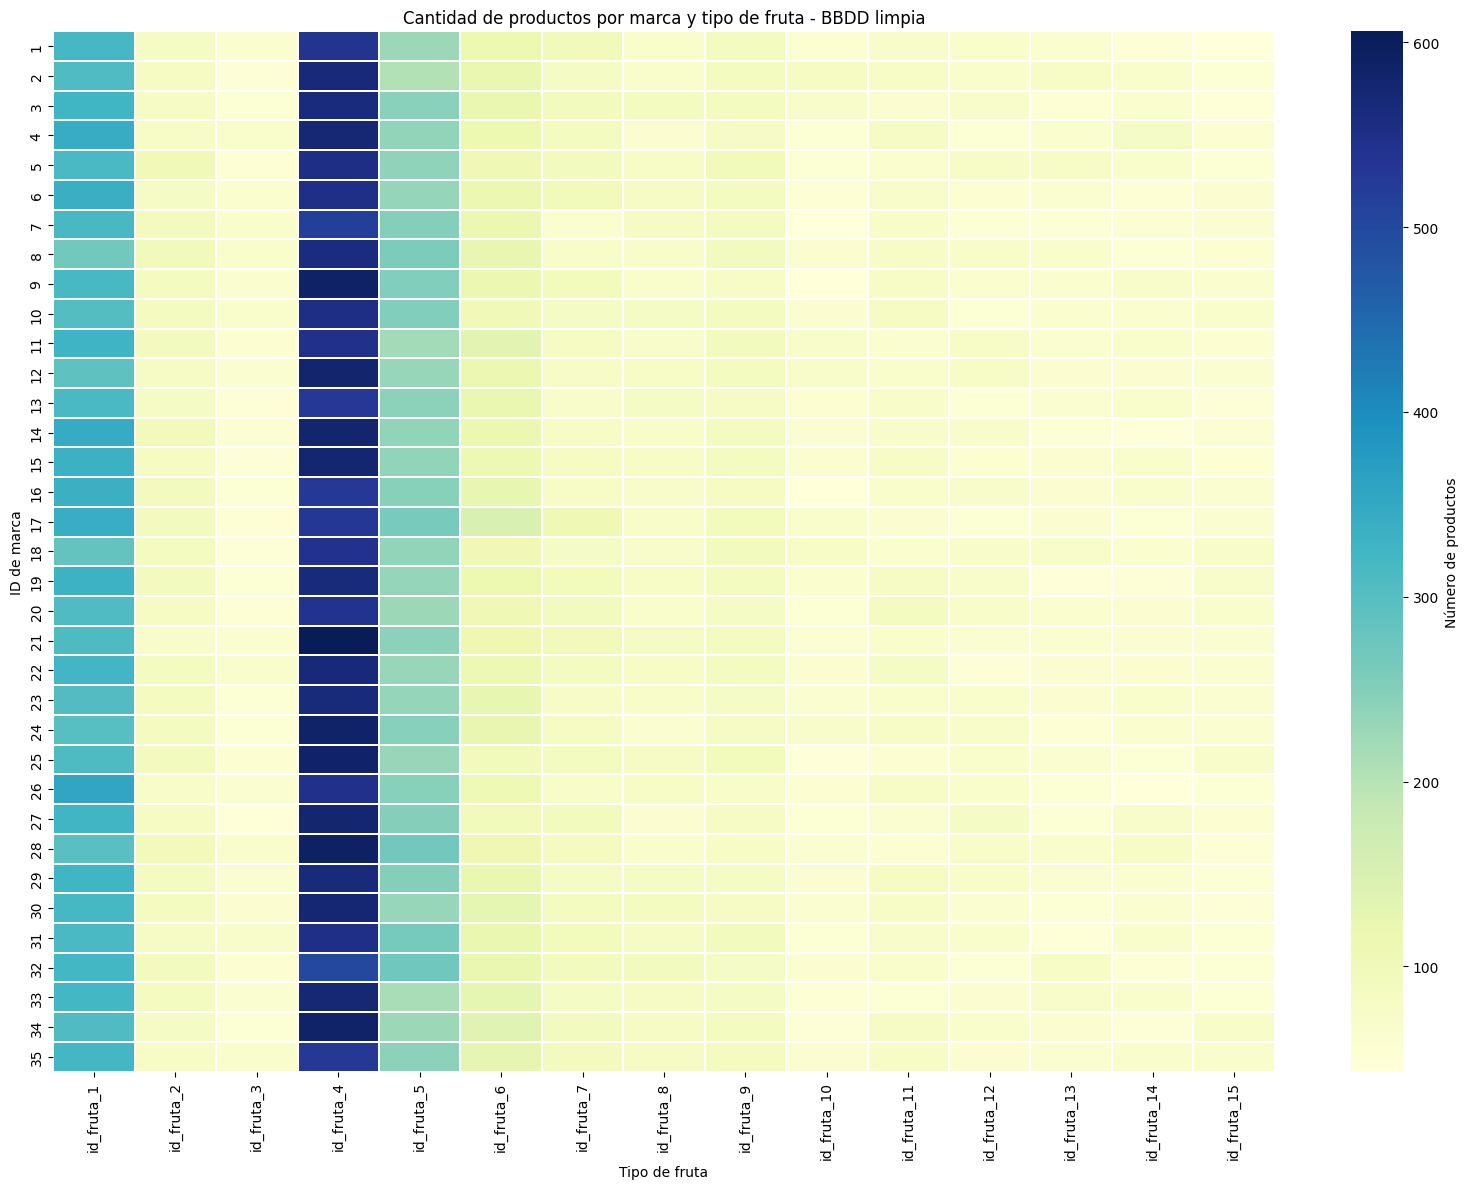

In [173]:
# ============================================================
# MAPA DE CALOR MARCA / TIPO DE FRUTA
# BBDD LIMPIA
# ============================================================

# Tabla cruzada:
# una fila por marca y una columna por tipo de fruta

df_marca_frutas_BBDD = pd.crosstab(
    index=df_producto_BBDD["id_marca"],
    columns=df_producto_BBDD["id_tipo"]
)


# Garantizamos que aparezcan los 15 tipos de fruta
df_marca_frutas_BBDD = (
    df_marca_frutas_BBDD
    .reindex(
        columns=range(1, 16),
        fill_value=0
    )
)


# Renombramos las columnas
df_marca_frutas_BBDD.columns = [
    f"id_fruta_{id_tipo}"
    for id_tipo in df_marca_frutas_BBDD.columns
]


# Convertimos id_marca nuevamente en columna
df_marca_frutas_BBDD = (
    df_marca_frutas_BBDD
    .reset_index()
)

df_marca_frutas_BBDD.columns.name = None


# ------------------------------------------------------------
# GRÁFICO
# ------------------------------------------------------------

df_grafico_marca_frutas_BBDD = (
    df_marca_frutas_BBDD
    .set_index("id_marca")
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    df_grafico_marca_frutas_BBDD,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.3,
    cbar_kws={
        "label": "Número de productos"
    }
)

plt.title(
    "Cantidad de productos por marca y tipo de fruta - BBDD limpia",
    fontsize=12
)

plt.xlabel("Tipo de fruta")
plt.ylabel("ID de marca")

plt.tight_layout()
plt.show()


####Decisión sobre el criterio 3:
La regla de negocio establece que una marca no puede producir más de un tipo de fruta. Sin embargo, el análisis muestra que esta relación no constituye una anomalía puntual, sino un patrón estructural del conjunto de datos: las marcas aparecen asociadas sistemáticamente a múltiples tipos de fruta.

Tras aplicar las operaciones de limpieza previas, el comportamiento se mantiene, por lo que no parece tratarse de registros aislados susceptibles de eliminación. Aplicar este criterio de forma estricta supondría descartar la práctica totalidad de las cadenas de información y haría inviable el uso posterior de la base de datos.

Por este motivo, el criterio se mantiene documentado como inconsistencia entre la regla de negocio y los datos disponibles, pero no se utiliza como criterio de exclusión para la construcción de la BBDD depurada.

Dada la dispersión, si sólo tuviéramos en cuenta las frutas que más distribuye cada marca como el valor correcto para esa marca; todas las marcas venderían únicamente id_fruta_4

###Criterio 4

In [175]:
# ============================================================
# CRITERIO 4
# Un mismo lote no puede tener marcas o tipos de fruta distintos
# BBDD LIMPIA
# ============================================================


# ------------------------------------------------------------
# 1. Información necesaria de los productos supervivientes
# ------------------------------------------------------------

df_lote_marca_tipo_c4_BBDD = (
    df_producto_BBDD[
        [
            "id_producto",
            "id_lote",
            "id_marca",
            "id_tipo"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. Resumen por lote
# ------------------------------------------------------------

df_resumen_lotes_c4_BBDD = (
    df_lote_marca_tipo_c4_BBDD
    .groupby(
        "id_lote",
        as_index=False
    )
    .agg(
        numero_productos=("id_producto", "nunique"),
        numero_marcas=("id_marca", "nunique"),
        numero_tipos_fruta=("id_tipo", "nunique")
    )
    .sort_values("id_lote")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. Identificamos los lotes que incumplen el criterio
# ------------------------------------------------------------

df_lotes_error_c4_BBDD = (
    df_resumen_lotes_c4_BBDD.loc[
        (df_resumen_lotes_c4_BBDD["numero_marcas"] > 1)
        |
        (df_resumen_lotes_c4_BBDD["numero_tipos_fruta"] > 1)
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Clasificamos el tipo de incidencia
# ------------------------------------------------------------

condiciones_c4 = [
    (
        (df_lotes_error_c4_BBDD["numero_marcas"] > 1)
        &
        (df_lotes_error_c4_BBDD["numero_tipos_fruta"] > 1)
    ),
    (
        (df_lotes_error_c4_BBDD["numero_marcas"] > 1)
        &
        (df_lotes_error_c4_BBDD["numero_tipos_fruta"] == 1)
    ),
    (
        (df_lotes_error_c4_BBDD["numero_marcas"] == 1)
        &
        (df_lotes_error_c4_BBDD["numero_tipos_fruta"] > 1)
    )
]

resultados_c4 = [
    "Lote con marcas y tipos de fruta distintos",
    "Lote con marcas distintas",
    "Lote con tipos de fruta distintos"
]

df_lotes_error_c4_BBDD["error_criterio_4"] = np.select(
    condiciones_c4,
    resultados_c4,
    default="Sin clasificar"
)


# ------------------------------------------------------------
# 5. Resumen
# ------------------------------------------------------------

resumen_errores_c4_BBDD = (
    df_lotes_error_c4_BBDD["error_criterio_4"]
    .value_counts()
    .rename_axis("tipo_error")
    .reset_index(name="numero_lotes")
)


total_lotes = (
    df_resumen_lotes_c4_BBDD["id_lote"].nunique()
)

lotes_error = (
    df_lotes_error_c4_BBDD["id_lote"].nunique()
)

lotes_validos = total_lotes - lotes_error


print(
    f"Lotes analizados: "
    f"{total_lotes:,}"
)

print(
    f"Lotes que cumplen el criterio: "
    f"{lotes_validos:,}"
)

print(
    f"Lotes que incumplen el criterio: "
    f"{lotes_error:,}"
)

print(
    f"Porcentaje de lotes con error: "
    f"{lotes_error / total_lotes * 100:.2f}%"
)

display(resumen_errores_c4_BBDD)


Lotes analizados: 69,220
Lotes que cumplen el criterio: 68,520
Lotes que incumplen el criterio: 700
Porcentaje de lotes con error: 1.01%


,tipo_error,numero_lotes
0,Lote con marcas y tipos de fruta distintos,493
1,Lote con marcas distintas,195
2,Lote con tipos de fruta distintos,12


In [176]:
# ============================================================
# PRODUCTOS AFECTADOS POR EL CRITERIO 4
# ============================================================

ids_lotes_error_c4 = set(
    df_lotes_error_c4_BBDD["id_lote"]
)

df_productos_error_c4_BBDD = (
    df_producto_BBDD[
        df_producto_BBDD["id_lote"].isin(
            ids_lotes_error_c4
        )
    ]
    .copy()
)

print(
    f"Productos pertenecientes a lotes conflictivos: "
    f"{df_productos_error_c4_BBDD['id_producto'].nunique():,}"
)

print(
    f"Porcentaje sobre productos de la BBDD: "
    f"{df_productos_error_c4_BBDD['id_producto'].nunique() / len(df_producto_BBDD) * 100:.2f}%"
)

Productos pertenecientes a lotes conflictivos: 1,664
Porcentaje sobre productos de la BBDD: 2.37%


Eliminamos los productos de los lotes conflictivos.

In [177]:
# ============================================================
# ELIMINAR PRODUCTOS DE LOTES CONFLICTIVOS
# CRITERIO 4
# ============================================================

# ------------------------------------------------------------
# Identificamos todos los id_producto pertenecientes
# a lotes que incumplen el criterio 4
# ------------------------------------------------------------

ids_productos_lotes_conflictivos = set(
    df_productos_error_c4_BBDD[
        "id_producto"
    ]
    .dropna()
    .drop_duplicates()
)


# ------------------------------------------------------------
# Comprobamos cuántos ya estaban eliminados
# por criterios anteriores
# ------------------------------------------------------------

ids_ya_eliminados = set(
    df_id_producto_eliminado["id_producto"]
)

ids_solapados_c4 = (
    ids_productos_lotes_conflictivos
    &
    ids_ya_eliminados
)

ids_nuevos_eliminados_c4 = (
    ids_productos_lotes_conflictivos
    -
    ids_ya_eliminados
)


print(
    f"Productos pertenecientes a lotes conflictivos: "
    f"{len(ids_productos_lotes_conflictivos):,}"
)

print(
    f"Ya eliminados por criterios anteriores: "
    f"{len(ids_solapados_c4):,}"
)

print(
    f"Nuevos productos eliminados por criterio 4: "
    f"{len(ids_nuevos_eliminados_c4):,}"
)


# ------------------------------------------------------------
# Añadimos los id_producto al dataframe acumulado
# de eliminados
# ------------------------------------------------------------

df_id_producto_eliminado = (
    pd.concat(
        [
            df_id_producto_eliminado,
            pd.DataFrame({
                "id_producto": list(
                    ids_productos_lotes_conflictivos
                )
            })
        ],
        ignore_index=True
    )
    .drop_duplicates(subset="id_producto")
    .sort_values("id_producto")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Reconstruimos los productos supervivientes
# ------------------------------------------------------------

df_id_producto_limpio = (
    df_producto.loc[
        ~df_producto["id_producto"].isin(
            df_id_producto_eliminado["id_producto"]
        ),
        ["id_producto"]
    ]
    .drop_duplicates()
    .sort_values("id_producto")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Comprobación acumulada
# ------------------------------------------------------------

print("\n--- RESULTADO ACUMULADO ---")

print(
    f"Productos originales: "
    f"{df_producto['id_producto'].nunique():,}"
)

print(
    f"Productos eliminados acumulados: "
    f"{len(df_id_producto_eliminado):,}"
)

print(
    f"Productos limpios restantes: "
    f"{len(df_id_producto_limpio):,}"
)

print(
    f"Comprobación total: "
    f"{len(df_id_producto_eliminado) + len(df_id_producto_limpio):,}"
)

Productos pertenecientes a lotes conflictivos: 1,664
Ya eliminados por criterios anteriores: 0
Nuevos productos eliminados por criterio 4: 1,664

--- RESULTADO ACUMULADO ---
Productos originales: 70,549
Productos eliminados acumulados: 2,022
Productos limpios restantes: 68,527
Comprobación total: 70,549


Regeneramos los df_BBDD no maestros

In [178]:
# ============================================================
# REGENERACIÓN ACUMULATIVA DE LA BBDD
# Tablas no maestras: PRODUCTO y VENTA
# ============================================================

# ------------------------------------------------------------
# 1. Universo actual de productos supervivientes
# ------------------------------------------------------------

ids_limpios = set(
    df_id_producto_limpio["id_producto"]
)


# ------------------------------------------------------------
# 2. Reconstruimos PRODUCTO y VENTA desde los originales
#    utilizando TODOS los criterios de eliminación acumulados
# ------------------------------------------------------------

df_producto_BBDD = (
    df_producto[
        df_producto["id_producto"].isin(ids_limpios)
    ]
    .copy()
    .reset_index(drop=True)
)

df_venta_BBDD = (
    df_venta[
        df_venta["id_producto"].isin(ids_limpios)
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 3. APLICAR COSTES CORREGIDOS
# ============================================================

if df_costes_nuevos["id_producto"].duplicated().any():
    raise ValueError(
        "Existen id_producto duplicados en df_costes_nuevos"
    )

mapa_costes = (
    df_costes_nuevos
    .set_index("id_producto")["coste_inicial"]
)

mascara_costes = (
    df_producto_BBDD["id_producto"]
    .isin(mapa_costes.index)
)

df_producto_BBDD.loc[
    mascara_costes,
    "coste_inicial"
] = (
    df_producto_BBDD.loc[
        mascara_costes,
        "id_producto"
    ]
    .map(mapa_costes)
    .to_numpy()
)


# ============================================================
# 4. APLICAR PRECIOS CORREGIDOS
# ============================================================

if df_precios_nuevos["id_producto"].duplicated().any():
    raise ValueError(
        "Existen id_producto duplicados en df_precios_nuevos"
    )

mapa_precios = (
    df_precios_nuevos
    .set_index("id_producto")["precio_venta"]
)

mascara_precios = (
    df_venta_BBDD["id_producto"]
    .isin(mapa_precios.index)
)

df_venta_BBDD.loc[
    mascara_precios,
    "precio_venta"
] = (
    df_venta_BBDD.loc[
        mascara_precios,
        "id_producto"
    ]
    .map(mapa_precios)
    .to_numpy()
)


# ============================================================
# 5. APLICAR TIEMPOS DE VENTA CORREGIDOS
# ============================================================

if df_tiempo_venta_nuevos["id_producto"].duplicated().any():
    raise ValueError(
        "Existen id_producto duplicados en "
        "df_tiempo_venta_nuevos"
    )

df_venta_BBDD["tiempo_venta"] = pd.to_datetime(
    df_venta_BBDD["tiempo_venta"],
    errors="coerce"
)

mapa_tiempos = (
    df_tiempo_venta_nuevos
    .set_index("id_producto")["tiempo_venta"]
)

mascara_tiempos = (
    df_venta_BBDD["id_producto"]
    .isin(mapa_tiempos.index)
)

df_venta_BBDD.loc[
    mascara_tiempos,
    "tiempo_venta"
] = (
    df_venta_BBDD.loc[
        mascara_tiempos,
        "id_producto"
    ]
    .map(mapa_tiempos)
    .to_numpy()
)


# ============================================================
# 6. COMPROBACIONES
# ============================================================

print("--- BBDD ACUMULATIVA ---")

print(
    f"Productos originales: "
    f"{df_producto['id_producto'].nunique():,}"
)

print(
    f"Productos eliminados acumulados: "
    f"{len(df_id_producto_eliminado):,}"
)

print(
    f"Productos supervivientes: "
    f"{len(df_id_producto_limpio):,}"
)

print(
    f"Registros en df_producto_BBDD: "
    f"{len(df_producto_BBDD):,}"
)

print(
    f"Registros en df_venta_BBDD: "
    f"{len(df_venta_BBDD):,}"
)


# Ningún producto eliminado debe seguir presente
eliminados_en_BBDD = (
    df_producto_BBDD["id_producto"]
    .isin(
        df_id_producto_eliminado["id_producto"]
    )
    .sum()
)

print(
    f"Productos eliminados presentes en la BBDD: "
    f"{eliminados_en_BBDD}"
)

--- BBDD ACUMULATIVA ---
Productos originales: 70,549
Productos eliminados acumulados: 2,022
Productos supervivientes: 68,527
Registros en df_producto_BBDD: 68,527
Registros en df_venta_BBDD: 68,527
Productos eliminados presentes en la BBDD: 0


##Exportación a CSV

In [179]:
# ============================================================
# EXPORTACIÓN DE LA BBDD LIMPIA A CSV PARA SQL
# ============================================================

tablas_SQL_limpios = {
    "cliente_SQL_limpios.csv": df_clientes_BBDD,
    "lote_SQL_limpios.csv": df_lote_BBDD,
    "marca_SQL_limpios.csv": df_marca_BBDD,
    "producto_SQL_limpios.csv": df_producto_BBDD,
    "proveedor_SQL_limpios.csv": df_proveedor_BBDD,
    "subtipo_SQL_limpios.csv": df_subtipo_BBDD,
    "tipo_SQL_limpios.csv": df_tipo_BBDD,
    "venta_SQL_limpios.csv": df_venta_BBDD
}


# ------------------------------------------------------------
# Exportación
# ------------------------------------------------------------

for nombre_archivo, dataframe in tablas_SQL_limpios.items():

    dataframe.to_csv(
        nombre_archivo,
        index=False,
        encoding="utf-8-sig",
        date_format="%Y-%m-%d %H:%M:%S"
    )

    print(
        f"{nombre_archivo}: "
        f"{len(dataframe):,} registros"
    )


print("\nExportación finalizada.")

cliente_SQL_limpios.csv: 34 registros
lote_SQL_limpios.csv: 69,567 registros
marca_SQL_limpios.csv: 35 registros
producto_SQL_limpios.csv: 68,527 registros
proveedor_SQL_limpios.csv: 35 registros
subtipo_SQL_limpios.csv: 27 registros
tipo_SQL_limpios.csv: 15 registros
venta_SQL_limpios.csv: 68,527 registros

Exportación finalizada.


In [180]:
# ============================================================
# ÚLTIMA COMPROBACIÓN
# ============================================================
print(
    "Producto:",
    len(df_producto_BBDD),
    "filas |",
    df_producto_BBDD["id_producto"].nunique(),
    "id_producto únicos"
)

print(
    "Venta:",
    len(df_venta_BBDD),
    "filas |",
    df_venta_BBDD["id_producto"].nunique(),
    "id_producto únicos"
)

print(
    "Mismos productos en producto y venta:",
    set(df_producto_BBDD["id_producto"])
    ==
    set(df_venta_BBDD["id_producto"])
)

Producto: 68527 filas | 68527 id_producto únicos
Venta: 68527 filas | 68527 id_producto únicos
Mismos productos en producto y venta: True


In [181]:
# ============================================================
# COMPRIMIR Y DESCARGAR TODOS LOS CSV LIMPIOS
# ============================================================

import zipfile
from google.colab import files

archivos_SQL_limpios = [
    "cliente_SQL_limpios.csv",
    "lote_SQL_limpios.csv",
    "marca_SQL_limpios.csv",
    "producto_SQL_limpios.csv",
    "proveedor_SQL_limpios.csv",
    "subtipo_SQL_limpios.csv",
    "tipo_SQL_limpios.csv",
    "venta_SQL_limpios.csv"
]

nombre_zip = "BBDD_SQL_limpios.zip"

with zipfile.ZipFile(
    nombre_zip,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for archivo in archivos_SQL_limpios:
        zipf.write(archivo)

files.download(nombre_zip)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>